<a href="https://colab.research.google.com/github/lswoodentoys/research_paper/blob/main/B%E1%BA%A3ng_t%E1%BB%95ng_h%E1%BB%A3p_h%E1%BB%87_s%E1%BB%91_t%C6%B0%C6%A1ng_quan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# BẢNG TỔNG HỢP NHÓM 1 - FULL UV (TỪ 295-385nm)

ASTM G177 vs UVA-340 SPECTRAL COMPARISON

Columns:
['Wavelength_nm', 'I_G177', 'I_UVA340']

Initial data:
   Wavelength_nm  I_G177  I_UVA340
0            280     0.0       0.0
1            281     0.0       0.0
2            282     0.0       0.0
3            283     0.0       0.0
4            284     0.0       0.0


SUMMARY COMPARISON TABLE
Range_nm  N  Chi_Square_Sum       SD        R  R_squared  Pearson  Spearman
 295-330 36        0.298003 0.092273 0.907727   0.969698 0.984732  0.992654
 295-320 26        0.242443 0.098477 0.901523   0.970393 0.985085  0.990050
 295-310 16        0.153696 0.101225 0.898775   0.968893 0.984324  0.984393
 295-300  6        0.071619 0.119682 0.880318   0.203071 0.450634  0.664211
 295-340 46        0.842272 0.136811 0.863189   0.941908 0.970519  0.971887
 295-350 56        1.756370 0.178701 0.821299   0.939078 0.969060  0.946904
 295-360 66        2.081734 0.178960 0.821040   0.934422 0.966655  0.901839
 295-370 76        2.569130 0.185081 0.814919   0

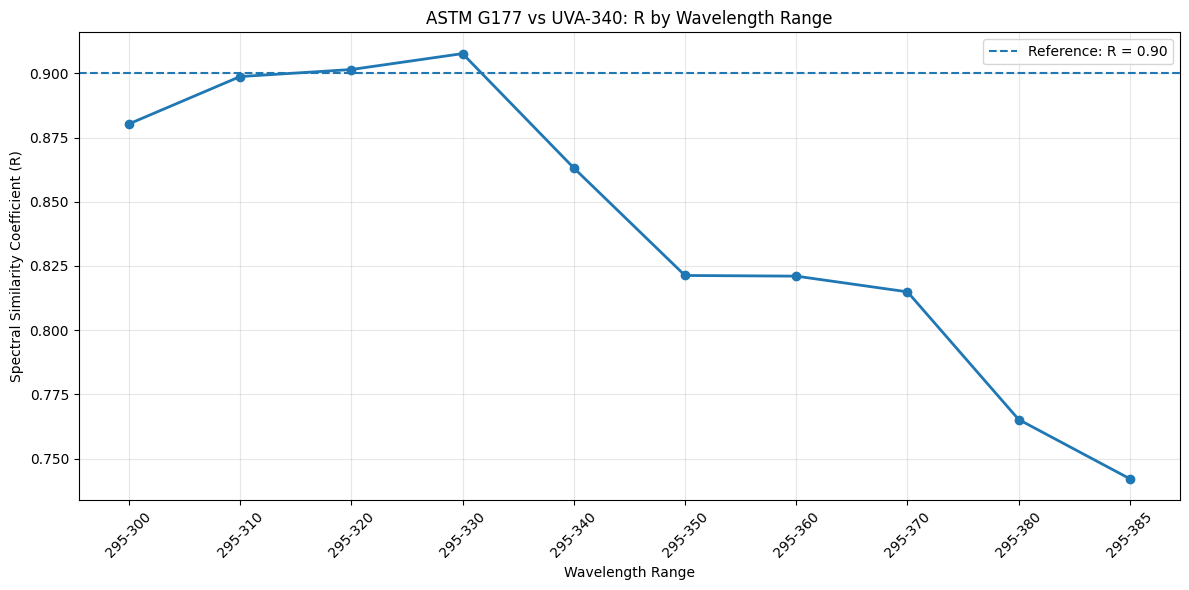

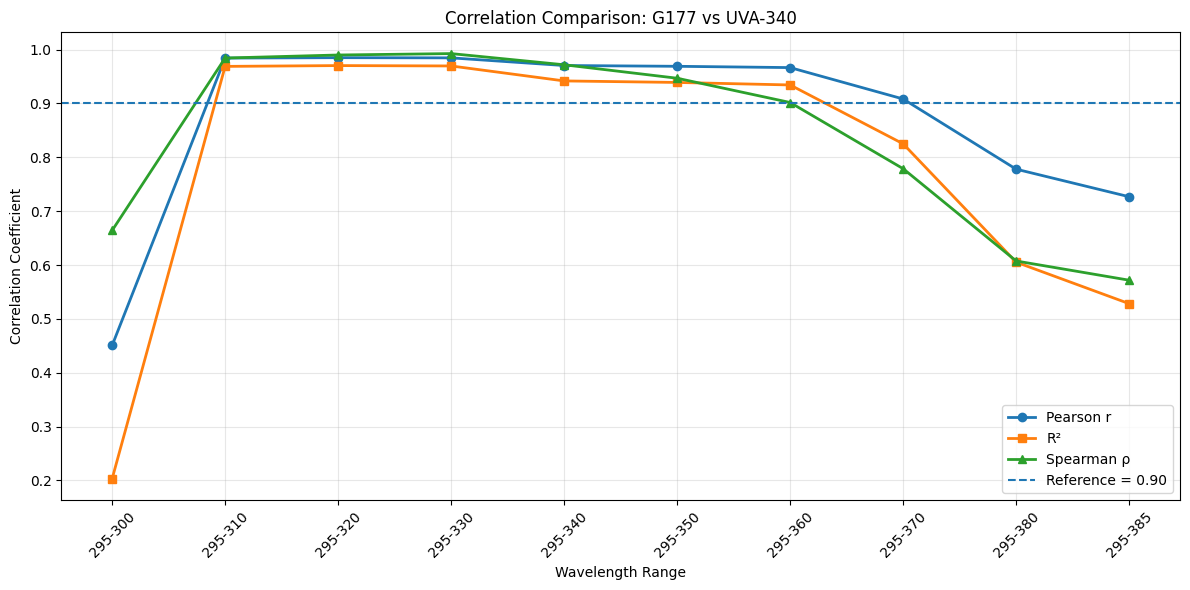

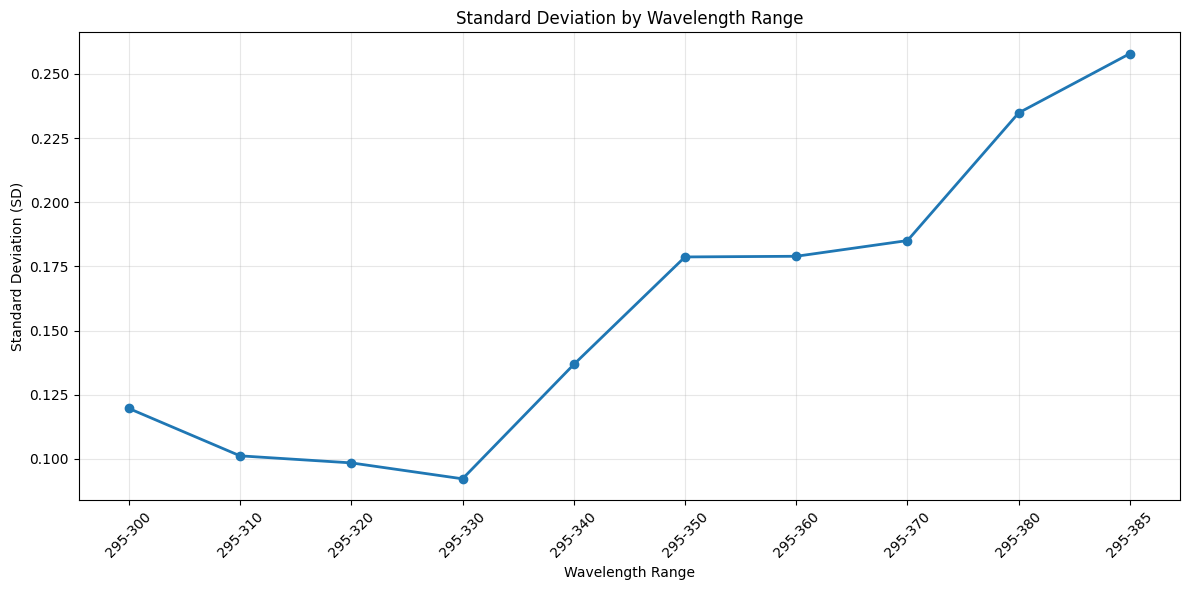

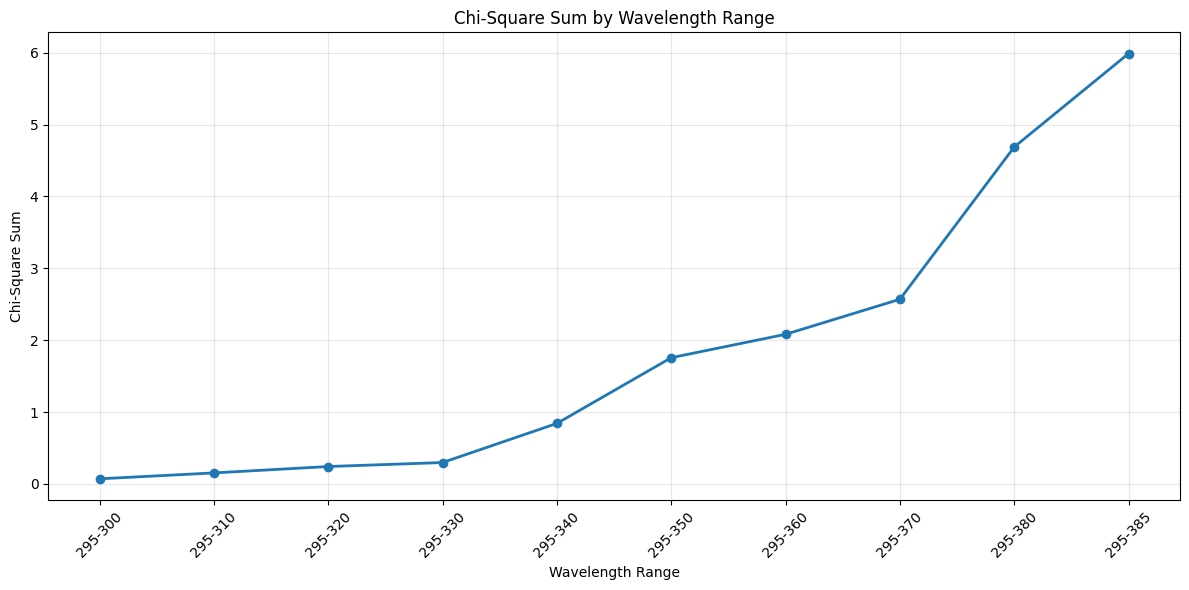

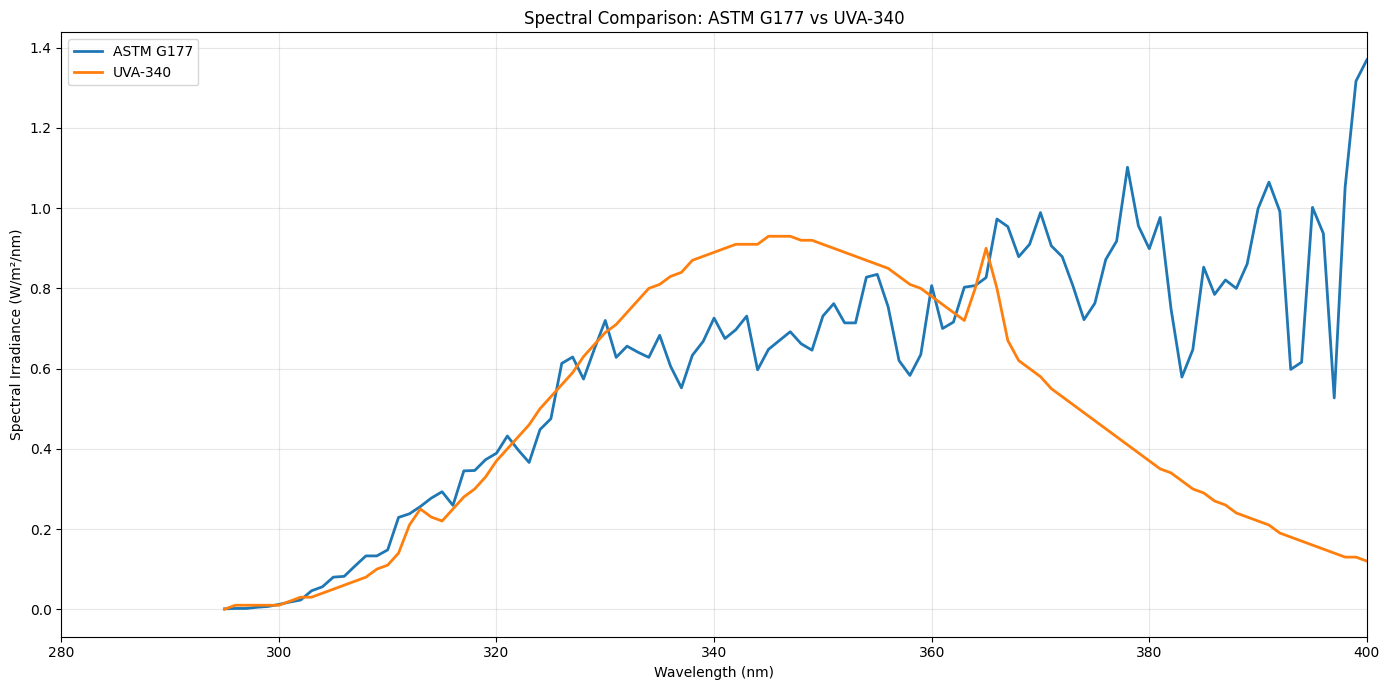

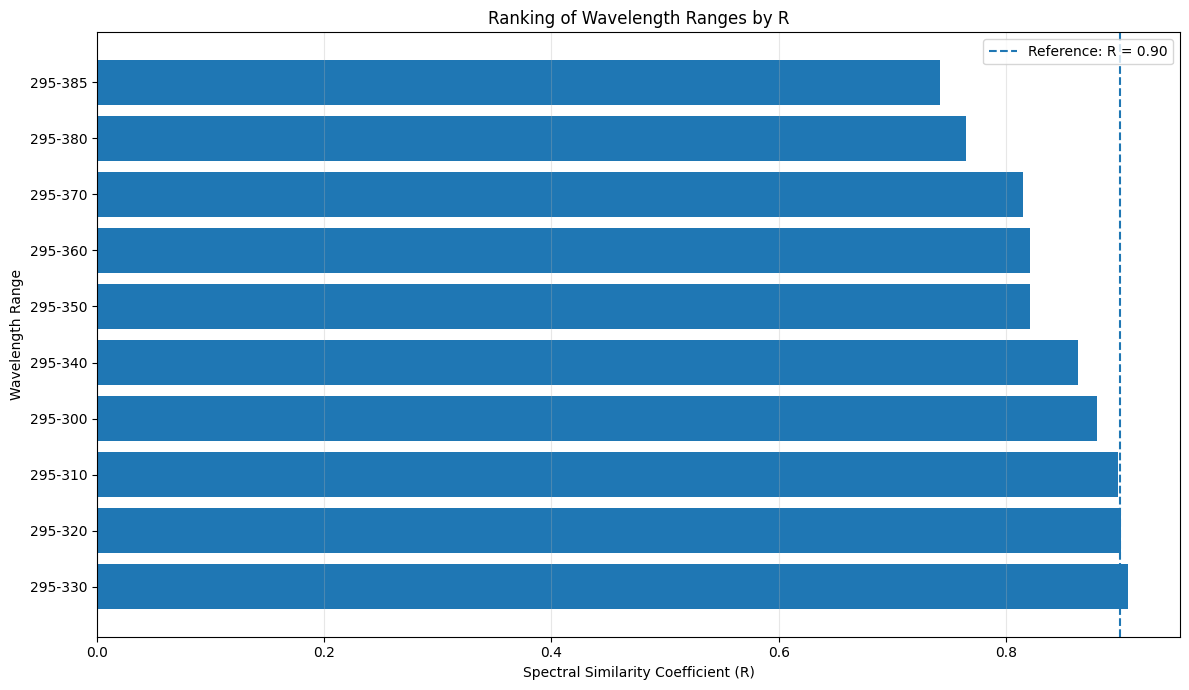



ANALYSIS COMPLETED

CSV:
/content/drive/MyDrive/Python_study/datasets/G177_UVA340_Comparison_Results.csv

Excel:
/content/drive/MyDrive/Python_study/datasets/G177_UVA340_Comparison_Results.xlsx

Number of wavelength ranges: 10


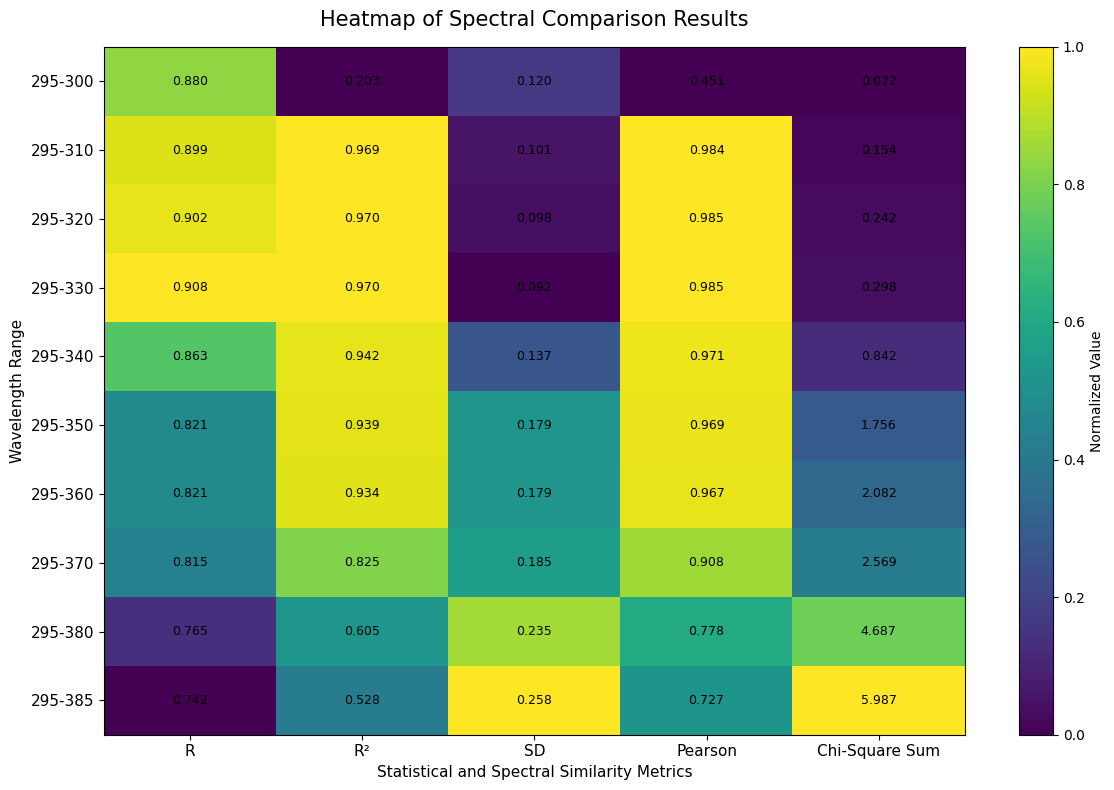

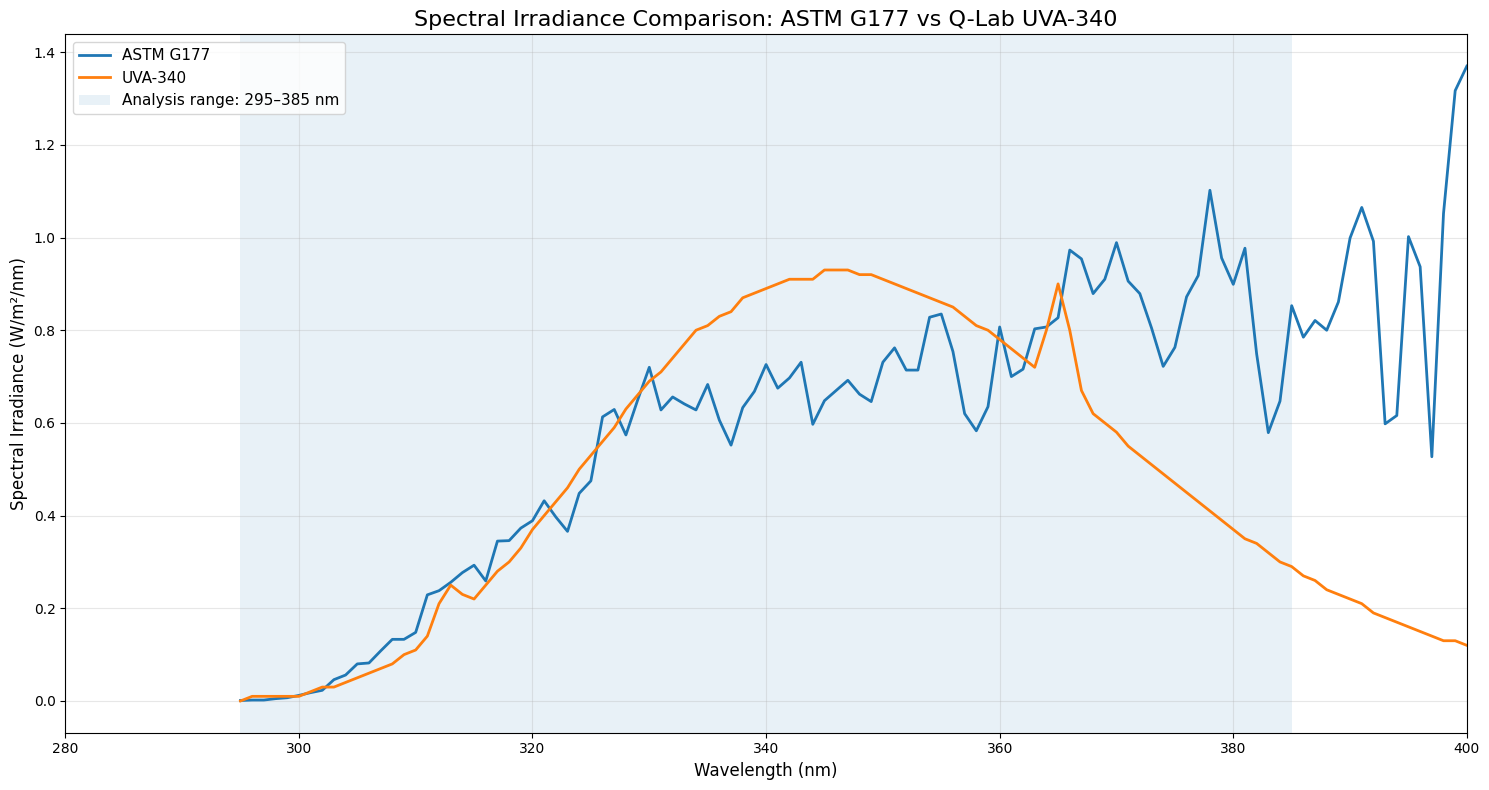

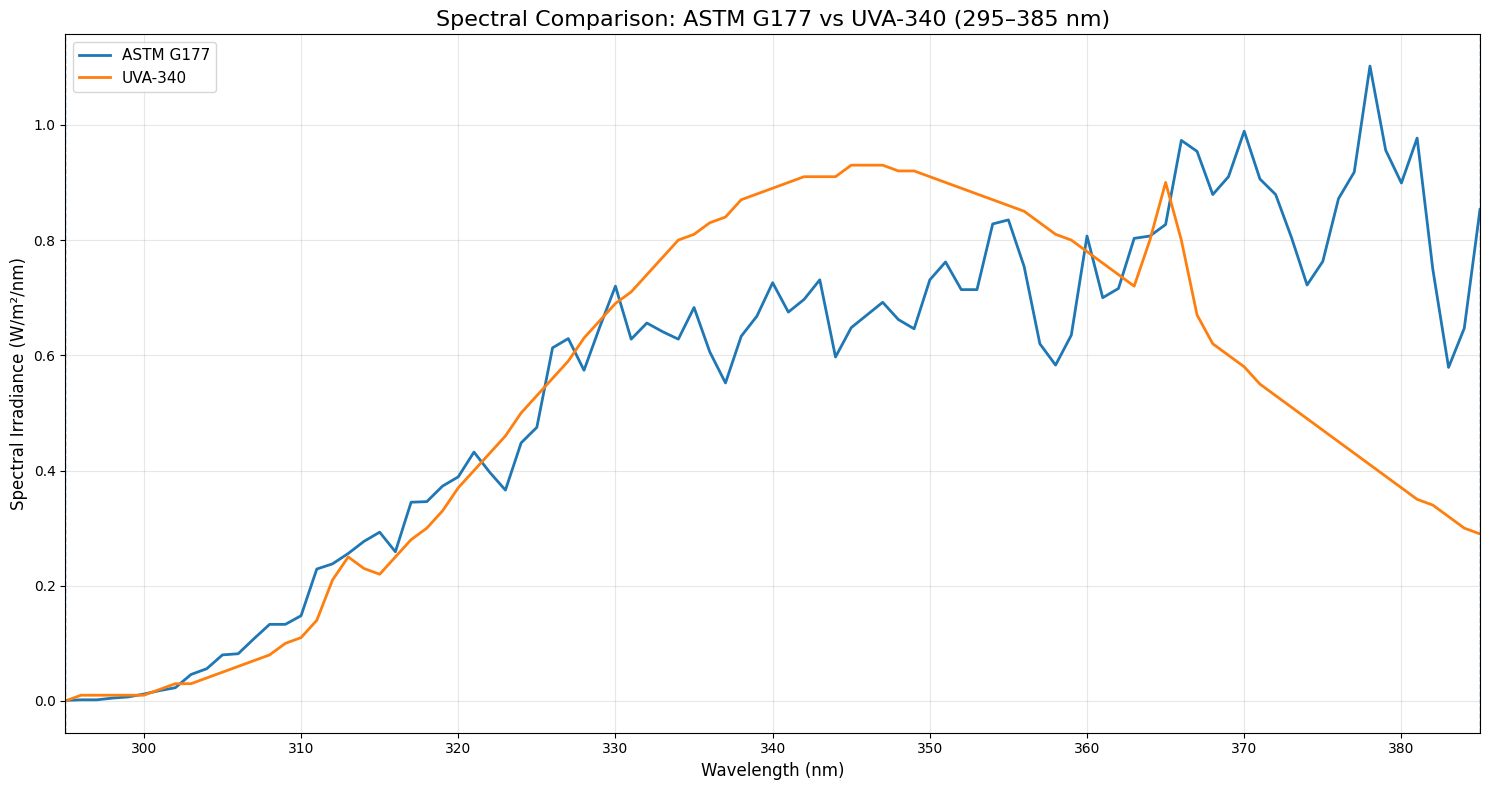

Heatmap data added to Excel.


In [14]:
# ============================================================
# ASTM G177 vs UVA-340
# SPECTRAL COMPARISON ANALYSIS
#
# Outputs:
#   1. Summary table
#   2. R, SD, Pearson, R², Spearman comparison charts
#   3. Chi-Square Sum chart
#   4. Spectral comparison chart
#   5. Excel file
#   6. CSV file
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr


# ============================================================
# 1. FILE PATH
# ============================================================

file_path = (
    '/content/drive/MyDrive/'
    'Python_study/datasets/'
    'spectral_data.csv'
)


# ============================================================
# 2. READ DATA
# ============================================================

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()


print("=" * 100)
print("ASTM G177 vs UVA-340 SPECTRAL COMPARISON")
print("=" * 100)

print("\nColumns:")
print(df.columns.tolist())

print("\nInitial data:")
print(df.head())


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Wavelength_nm",
    "I_G177",
    "I_UVA340"
]


missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ============================================================
# 4. CONVERT TO NUMERIC
# ============================================================

for col in required_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 5. CLEAN DATA
# ============================================================

df = df.dropna(
    subset=required_columns
).copy()


# G177 must be > 0
df = df[
    df["I_G177"] > 0
].copy()


# Sort
df = df.sort_values(
    "Wavelength_nm"
)


# Remove duplicate wavelength
df = df.groupby(
    "Wavelength_nm",
    as_index=False
)[
    ["I_G177", "I_UVA340"]
].mean()


# ============================================================
# 6. WAVELENGTH RANGES
# ============================================================

lambda_min = 295

lambda_max_list = [
    300,
    310,
    320,
    330,
    340,
    350,
    360,
    370,
    380,
    385
]


# ============================================================
# 7. CALCULATION
# ============================================================

results = []

calculation_details = {}


for lambda_max in lambda_max_list:

    # --------------------------------------------------------
    # Select wavelength range
    # --------------------------------------------------------

    df_range = df[
        (df["Wavelength_nm"] >= lambda_min)
        &
        (df["Wavelength_nm"] <= lambda_max)
    ].copy()


    # --------------------------------------------------------
    # Check number of points
    # --------------------------------------------------------

    if len(df_range) < 2:

        print(
            f"WARNING: Not enough data for "
            f"{lambda_min}-{lambda_max} nm"
        )

        continue


    # --------------------------------------------------------
    # Difference
    # --------------------------------------------------------

    df_range["Difference"] = (
        df_range["I_G177"]
        -
        df_range["I_UVA340"]
    )


    # --------------------------------------------------------
    # Squared Difference
    # --------------------------------------------------------

    df_range["Squared_Difference"] = (
        df_range["Difference"] ** 2
    )


    # --------------------------------------------------------
    # Chi-Square Term
    #
    # (G177 - UVA340)^2 / G177
    # --------------------------------------------------------

    df_range["Chi_Square_Term"] = (

        df_range["Squared_Difference"]
        /
        df_range["I_G177"]

    )


    # --------------------------------------------------------
    # Chi-Square Sum
    # --------------------------------------------------------

    chi_square_sum = (
        df_range["Chi_Square_Term"].sum()
    )


    # --------------------------------------------------------
    # Denominator
    #
    # EXACTLY according to user's formula:
    #
    # x - 295
    # --------------------------------------------------------

    denominator = (
        lambda_max
        -
        lambda_min
    )


    # --------------------------------------------------------
    # Standard Deviation
    # --------------------------------------------------------

    SD = np.sqrt(
        chi_square_sum
        /
        denominator
    )


    # --------------------------------------------------------
    # Spectral Similarity Coefficient R
    #
    # R = 1 - SD
    # --------------------------------------------------------

    R = 1 - SD


    # ========================================================
    # PEARSON
    # ========================================================

    Pearson, Pearson_p = pearsonr(
        df_range["I_G177"],
        df_range["I_UVA340"]
    )


    # ========================================================
    # SPEARMAN
    # ========================================================

    Spearman, Spearman_p = spearmanr(
        df_range["I_G177"],
        df_range["I_UVA340"]
    )


    # ========================================================
    # R²
    #
    # R² = Pearson²
    # ========================================================

    R_squared = Pearson ** 2


    # ========================================================
    # SAVE RESULT
    # ========================================================

    results.append({

        "Range_nm":
            f"{lambda_min}-{lambda_max}",

        "Lambda_Min_nm":
            lambda_min,

        "Lambda_Max_nm":
            lambda_max,

        "N":
            len(df_range),

        "Chi_Square_Sum":
            chi_square_sum,

        "SD":
            SD,

        "R":
            R,

        "Pearson":
            Pearson,

        "Pearson_p":
            Pearson_p,

        "R_squared":
            R_squared,

        "Spearman":
            Spearman,

        "Spearman_p":
            Spearman_p

    })


    # --------------------------------------------------------
    # Save detailed calculation
    # --------------------------------------------------------

    calculation_details[
        f"{lambda_min}-{lambda_max}"
    ] = df_range.copy()


# ============================================================
# 8. CREATE SUMMARY DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 9. SORT BY R DESCENDING
# ============================================================

results_df = results_df.sort_values(
    by="R",
    ascending=False
).reset_index(
    drop=True
)


# ============================================================
# 10. DISPLAY TABLE
# ============================================================

results_display = results_df.copy()


numeric_columns = [
    "Chi_Square_Sum",
    "SD",
    "R",
    "Pearson",
    "Pearson_p",
    "R_squared",
    "Spearman",
    "Spearman_p"
]


for col in numeric_columns:

    results_display[col] = (
        results_display[col].round(6)
    )


print("\n")
print("=" * 130)
print("SUMMARY COMPARISON TABLE")
print("=" * 130)


print(
    results_display[
        [
            "Range_nm",
            "N",
            "Chi_Square_Sum",
            "SD",
            "R",
            "R_squared",
            "Pearson",
            "Spearman"
        ]
    ].to_string(index=False)
)


# ============================================================
# 11. CHART 1
# R COMPARISON
# ============================================================

plot_df = results_df.sort_values(
    "Lambda_Max_nm"
)


plt.figure(
    figsize=(12, 6)
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["R"],
    marker="o",
    linewidth=2
)


plt.axhline(
    y=0.90,
    linestyle="--",
    linewidth=1.5,
    label="Reference: R = 0.90"
)


plt.xlabel(
    "Wavelength Range"
)

plt.ylabel(
    "Spectral Similarity Coefficient (R)"
)

plt.title(
    "ASTM G177 vs UVA-340: R by Wavelength Range"
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. CHART 2
# R², PEARSON AND SPEARMAN
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["Pearson"],
    marker="o",
    linewidth=2,
    label="Pearson r"
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["R_squared"],
    marker="s",
    linewidth=2,
    label="R²"
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["Spearman"],
    marker="^",
    linewidth=2,
    label="Spearman ρ"
)


plt.axhline(
    y=0.90,
    linestyle="--",
    linewidth=1.5,
    label="Reference = 0.90"
)


plt.xlabel(
    "Wavelength Range"
)

plt.ylabel(
    "Correlation Coefficient"
)

plt.title(
    "Correlation Comparison: G177 vs UVA-340"
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. CHART 3
# SD COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["SD"],
    marker="o",
    linewidth=2
)


plt.xlabel(
    "Wavelength Range"
)

plt.ylabel(
    "Standard Deviation (SD)"
)

plt.title(
    "Standard Deviation by Wavelength Range"
)


plt.grid(
    True,
    alpha=0.3
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. CHART 4
# CHI-SQUARE SUM
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["Chi_Square_Sum"],
    marker="o",
    linewidth=2
)


plt.xlabel(
    "Wavelength Range"
)

plt.ylabel(
    "Chi-Square Sum"
)

plt.title(
    "Chi-Square Sum by Wavelength Range"
)


plt.grid(
    True,
    alpha=0.3
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. CHART 5
# G177 vs UVA-340 SPECTRAL CURVES
# ============================================================

plt.figure(
    figsize=(14, 7)
)


plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    linewidth=2,
    label="ASTM G177"
)


plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    linewidth=2,
    label="UVA-340"
)


plt.xlabel(
    "Wavelength (nm)"
)

plt.ylabel(
    "Spectral Irradiance (W/m²/nm)"
)

plt.title(
    "Spectral Comparison: ASTM G177 vs UVA-340"
)


plt.xlim(
    280,
    400
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 16. CHART 6
# RANKING OF WAVELENGTH RANGES
# ============================================================

ranking_df = results_df.sort_values(
    by="R",
    ascending=False
)


plt.figure(
    figsize=(12, 7)
)


plt.barh(
    ranking_df["Range_nm"],
    ranking_df["R"]
)


plt.xlabel(
    "Spectral Similarity Coefficient (R)"
)

plt.ylabel(
    "Wavelength Range"
)

plt.title(
    "Ranking of Wavelength Ranges by R"
)


plt.axvline(
    x=0.90,
    linestyle="--",
    linewidth=1.5,
    label="Reference: R = 0.90"
)


plt.legend()

plt.grid(
    axis="x",
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# 17. EXPORT CSV
# ============================================================

output_csv = (
    "/content/drive/MyDrive/"
    "Python_study/datasets/"
    "G177_UVA340_Comparison_Results.csv"
)


results_display.to_csv(
    output_csv,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. EXPORT EXCEL
# ============================================================

output_excel = (
    "/content/drive/MyDrive/"
    "Python_study/datasets/"
    "G177_UVA340_Comparison_Results.xlsx"
)


with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:


    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    results_display.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )


    # --------------------------------------------------------
    # DETAILED CALCULATIONS
    # --------------------------------------------------------

    for range_name, detail_df in calculation_details.items():

        sheet_name = (
            "Detail_"
            +
            range_name.replace("-", "_")
            +
            "nm"
        )

        detail_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )


    # --------------------------------------------------------
    # FORMAT EXCEL
    # --------------------------------------------------------

    workbook = writer.book


    for worksheet in workbook.worksheets:

        worksheet.freeze_panes = "A2"


        for column_cells in worksheet.columns:

            max_length = 0

            column_letter = (
                column_cells[0].column_letter
            )


            for cell in column_cells:

                try:

                    cell_length = len(
                        str(cell.value)
                    )

                    max_length = max(
                        max_length,
                        cell_length
                    )

                except:

                    pass


            worksheet.column_dimensions[
                column_letter
            ].width = min(
                max_length + 2,
                30
            )


# ============================================================
# 19. FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 100)
print("ANALYSIS COMPLETED")
print("=" * 100)

print(
    f"\nCSV:\n{output_csv}"
)

print(
    f"\nExcel:\n{output_excel}"
)

print(
    "\nNumber of wavelength ranges:",
    len(results_df)
)

# ============================================================
# 20. HEATMAP 10 × 5
#
# Rows    = wavelength ranges
# Columns = R, R², SD, Pearson, Chi-Square Sum
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Create heatmap data
# ------------------------------------------------------------

heatmap_df = results_df.sort_values(
    "Lambda_Max_nm"
).copy()


heatmap_df = heatmap_df[
    [
        "Range_nm",
        "R",
        "R_squared",
        "SD",
        "Pearson",
        "Chi_Square_Sum"
    ]
].set_index(
    "Range_nm"
)


# ------------------------------------------------------------
# Normalize each column separately
#
# This is important because:
# R, R², SD and Chi-Square have different scales.
# ------------------------------------------------------------

heatmap_normalized = heatmap_df.copy()


for col in heatmap_normalized.columns:

    col_min = heatmap_normalized[col].min()
    col_max = heatmap_normalized[col].max()

    if col_max != col_min:

        heatmap_normalized[col] = (
            heatmap_normalized[col] - col_min
        ) / (
            col_max - col_min
        )

    else:

        heatmap_normalized[col] = 1


# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 8)
)


im = ax.imshow(
    heatmap_normalized.values,
    aspect="auto"
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(
        len(heatmap_normalized.columns)
    )
)

ax.set_xticklabels(
    [
        "R",
        "R²",
        "SD",
        "Pearson",
        "Chi-Square Sum"
    ],
    fontsize=11
)


ax.set_yticks(
    np.arange(
        len(heatmap_normalized.index)
    )
)

ax.set_yticklabels(
    heatmap_normalized.index,
    fontsize=11
)


# ------------------------------------------------------------
# Display original values inside cells
# ------------------------------------------------------------

for i in range(
    len(heatmap_normalized.index)
):

    for j in range(
        len(heatmap_normalized.columns)
    ):

        original_value = (
            heatmap_df.iloc[i, j]
        )

        ax.text(
            j,
            i,
            f"{original_value:.3f}",
            ha="center",
            va="center",
            fontsize=9
        )


# ------------------------------------------------------------
# Titles
# ------------------------------------------------------------

ax.set_title(
    "Heatmap of Spectral Comparison Results",
    fontsize=15,
    pad=15
)

ax.set_xlabel(
    "Statistical and Spectral Similarity Metrics",
    fontsize=11
)

ax.set_ylabel(
    "Wavelength Range",
    fontsize=11
)


# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Normalized Value",
    fontsize=10
)


plt.tight_layout()

plt.show()

# ============================================================
# 21. FULL SPECTRAL PLOT
# ASTM G177 vs UVA-340
# 280–400 nm
# ============================================================

plt.figure(
    figsize=(15, 8)
)


# ------------------------------------------------------------
# ASTM G177
# ------------------------------------------------------------

plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    linewidth=2,
    label="ASTM G177"
)


# ------------------------------------------------------------
# UVA-340
# ------------------------------------------------------------

plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    linewidth=2,
    label="UVA-340"
)


# ------------------------------------------------------------
# Highlight analysis region
# ------------------------------------------------------------

plt.axvspan(
    295,
    385,
    alpha=0.10,
    label="Analysis range: 295–385 nm"
)


# ------------------------------------------------------------
# Axis
# ------------------------------------------------------------

plt.xlabel(
    "Wavelength (nm)",
    fontsize=12
)

plt.ylabel(
    "Spectral Irradiance (W/m²/nm)",
    fontsize=12
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(
    "Spectral Irradiance Comparison: "
    "ASTM G177 vs Q-Lab UVA-340",
    fontsize=16
)


# ------------------------------------------------------------
# X-axis
# ------------------------------------------------------------

plt.xlim(
    280,
    400
)


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

plt.grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

plt.legend(
    fontsize=11
)


plt.tight_layout()

plt.show()

# ============================================================
# 22. ZOOMED SPECTRAL PLOT
# 295–385 nm
# ============================================================

df_zoom = df[
    (df["Wavelength_nm"] >= 295)
    &
    (df["Wavelength_nm"] <= 385)
].copy()


plt.figure(
    figsize=(15, 8)
)


plt.plot(
    df_zoom["Wavelength_nm"],
    df_zoom["I_G177"],
    linewidth=2,
    label="ASTM G177"
)


plt.plot(
    df_zoom["Wavelength_nm"],
    df_zoom["I_UVA340"],
    linewidth=2,
    label="UVA-340"
)


# ------------------------------------------------------------
# Mark range boundaries
# ------------------------------------------------------------

plt.axvline(
    295,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    385,
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    "Wavelength (nm)",
    fontsize=12
)

plt.ylabel(
    "Spectral Irradiance (W/m²/nm)",
    fontsize=12
)


plt.title(
    "Spectral Comparison: ASTM G177 vs UVA-340 "
    "(295–385 nm)",
    fontsize=16
)


plt.xlim(
    295,
    385
)


plt.grid(
    True,
    alpha=0.3
)


plt.legend(
    fontsize=11
)


plt.tight_layout()

plt.show()

# ============================================================
# 23. EXPORT HEATMAP DATA TO EXCEL
# ============================================================

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    # Raw values
    heatmap_df.to_excel(
        writer,
        sheet_name="Heatmap_Data"
    )

    # Normalized values
    heatmap_normalized.to_excel(
        writer,
        sheet_name="Heatmap_Normalized"
    )


print(
    "Heatmap data added to Excel."
)

# BẢNG TỔNG HỢP NHÓM 2 - CHỈ CÓ UVA (TỪ 320-385nm)

ASTM G177 vs UVA-340 SPECTRAL COMPARISON

Columns:
['Wavelength_nm', 'I_G177', 'I_UVA340']

Initial data:
   Wavelength_nm  I_G177  I_UVA340
0            280     0.0       0.0
1            281     0.0       0.0
2            282     0.0       0.0
3            283     0.0       0.0
4            284     0.0       0.0


SUMMARY COMPARISON TABLE
Range_nm  N  Chi_Square_Sum       SD        R  R_squared   Pearson  Spearman
 320-330 11        0.056488 0.075159 0.924841   0.842739  0.918008  0.909091
 320-340 21        0.600758 0.173314 0.826686   0.675778  0.822057  0.728159
 320-360 41        1.840219 0.214489 0.785511   0.603917  0.777121  0.593373
 320-370 51        2.327615 0.215760 0.784240   0.167157  0.408849  0.269559
 320-350 31        1.514855 0.224711 0.775289   0.688334  0.829659  0.693932
 320-380 61        4.445800 0.272207 0.727793   0.002722 -0.052174 -0.098880
 320-385 66        5.745076 0.297297 0.702703   0.006854 -0.082787 -0.115207


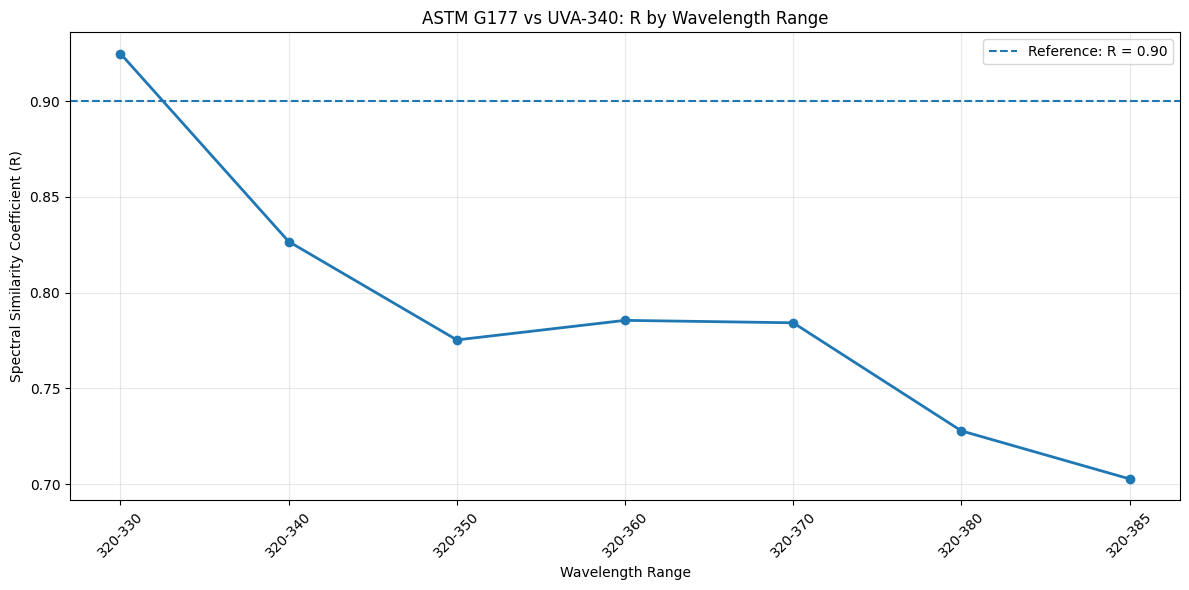

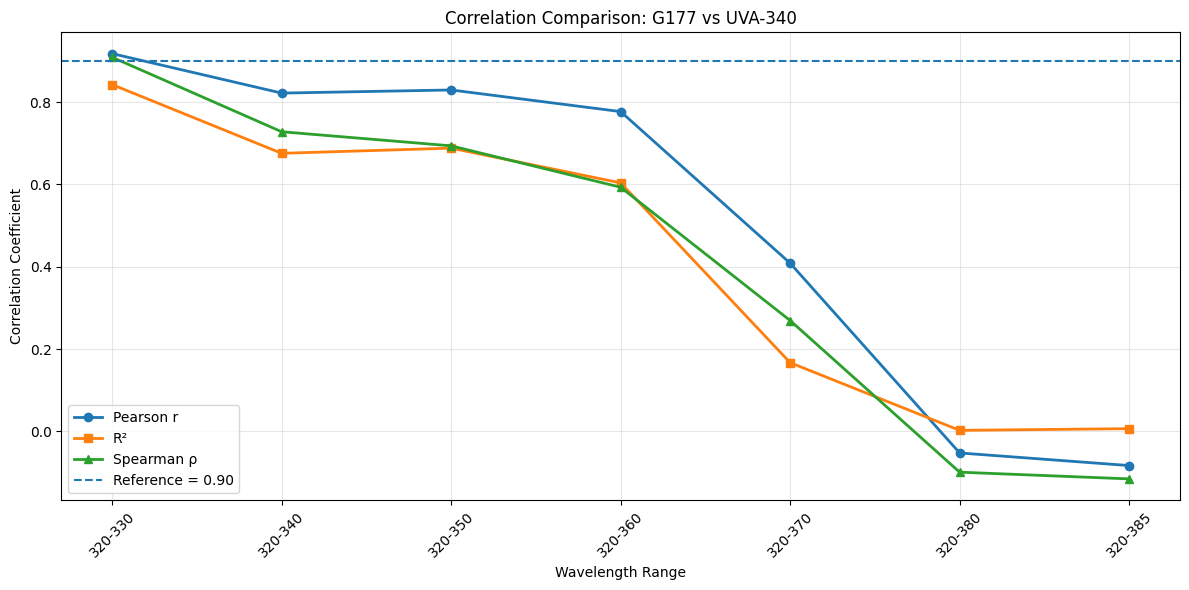

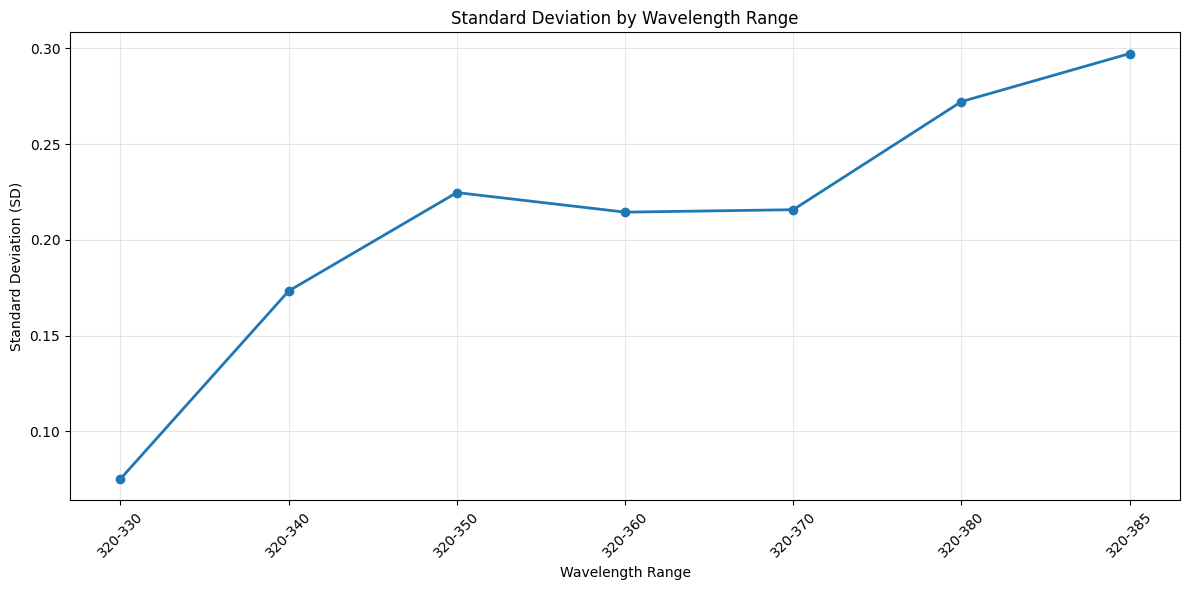

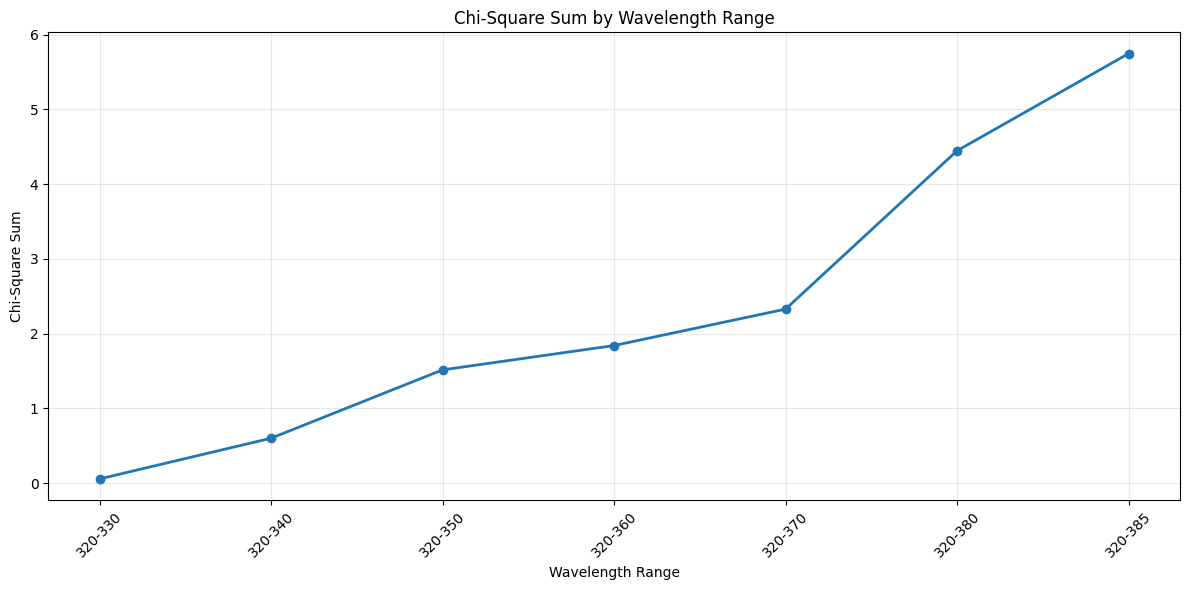

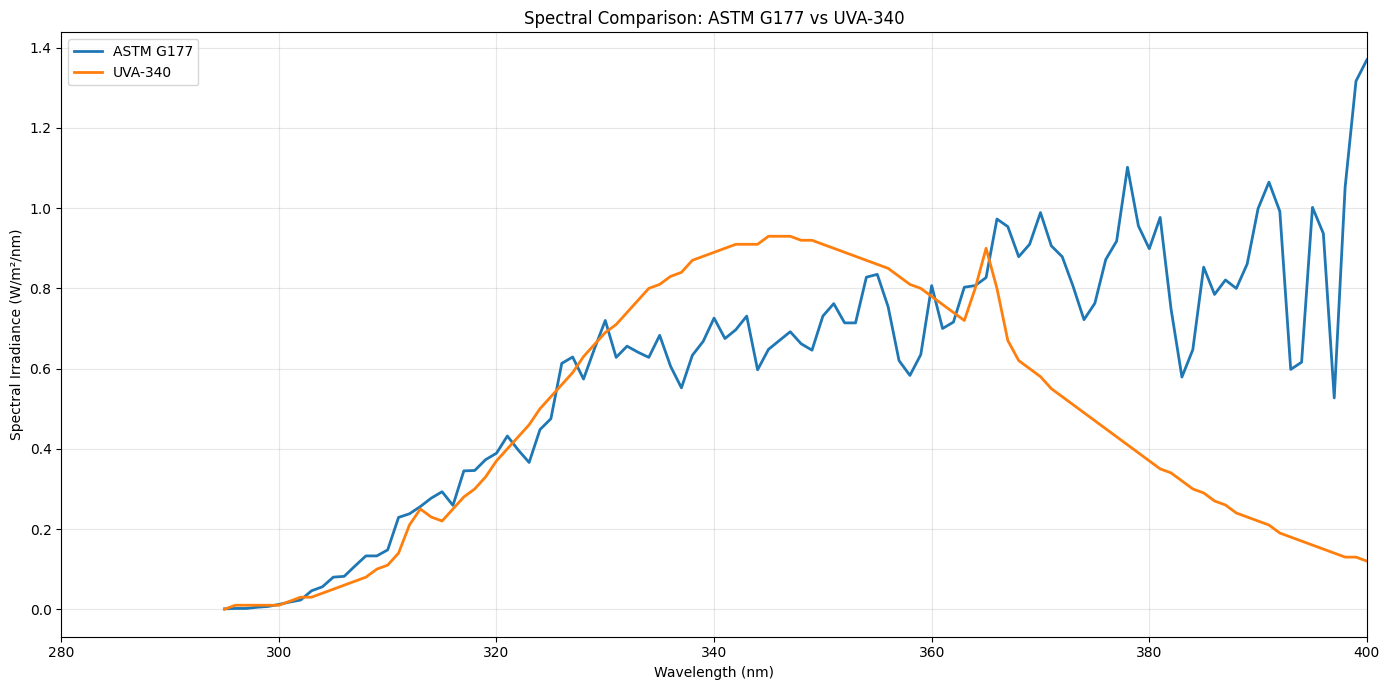

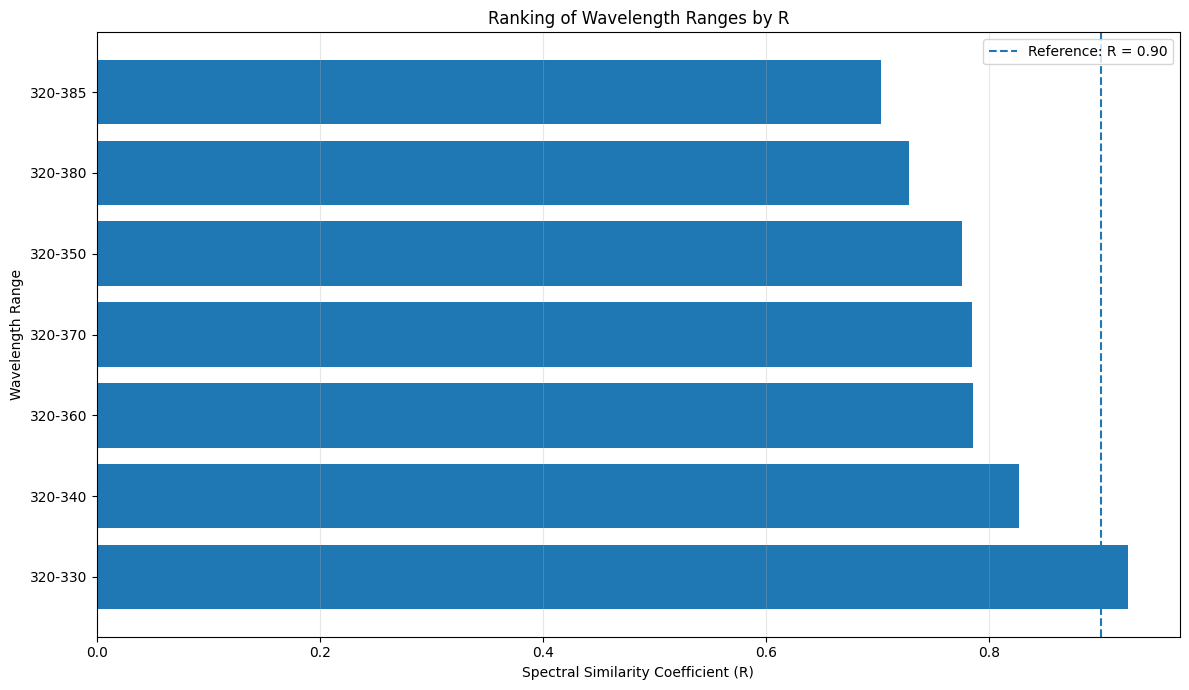



ANALYSIS COMPLETED

CSV:
/content/drive/MyDrive/Python_study/datasets/G177_UVA340_Comparison_Results.csv

Excel:
/content/drive/MyDrive/Python_study/datasets/G177_UVA340_Comparison_Results.xlsx

Number of wavelength ranges: 7


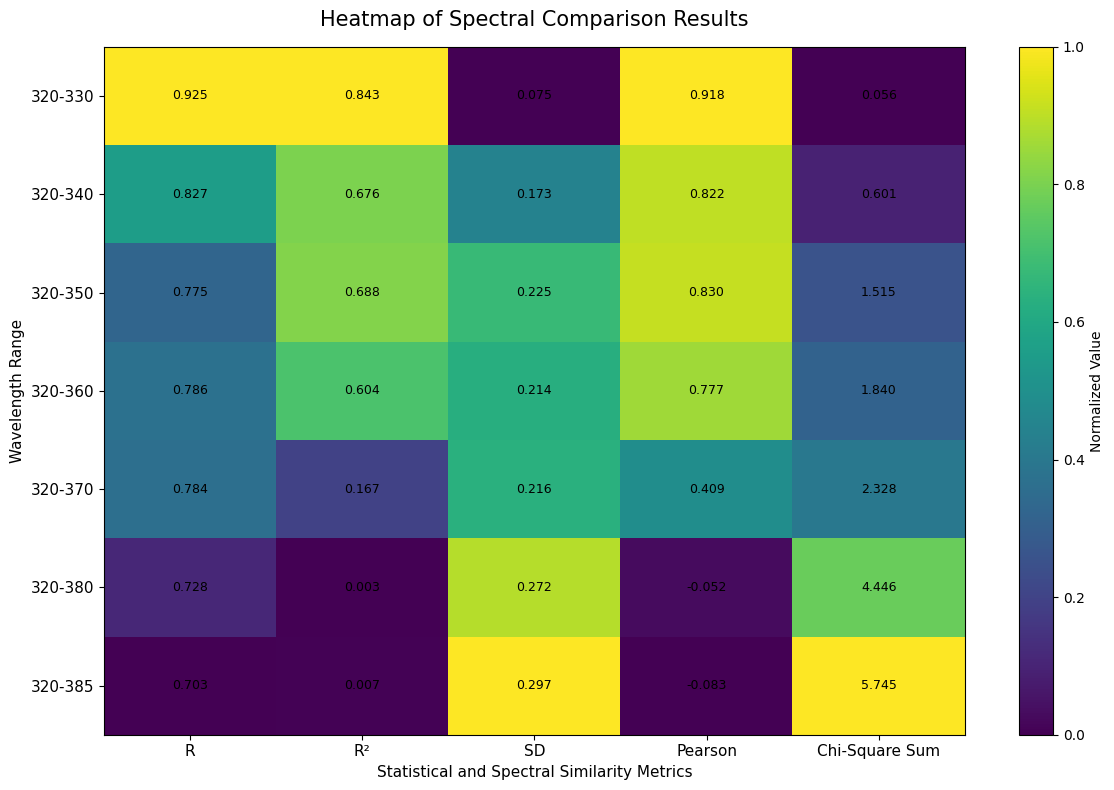

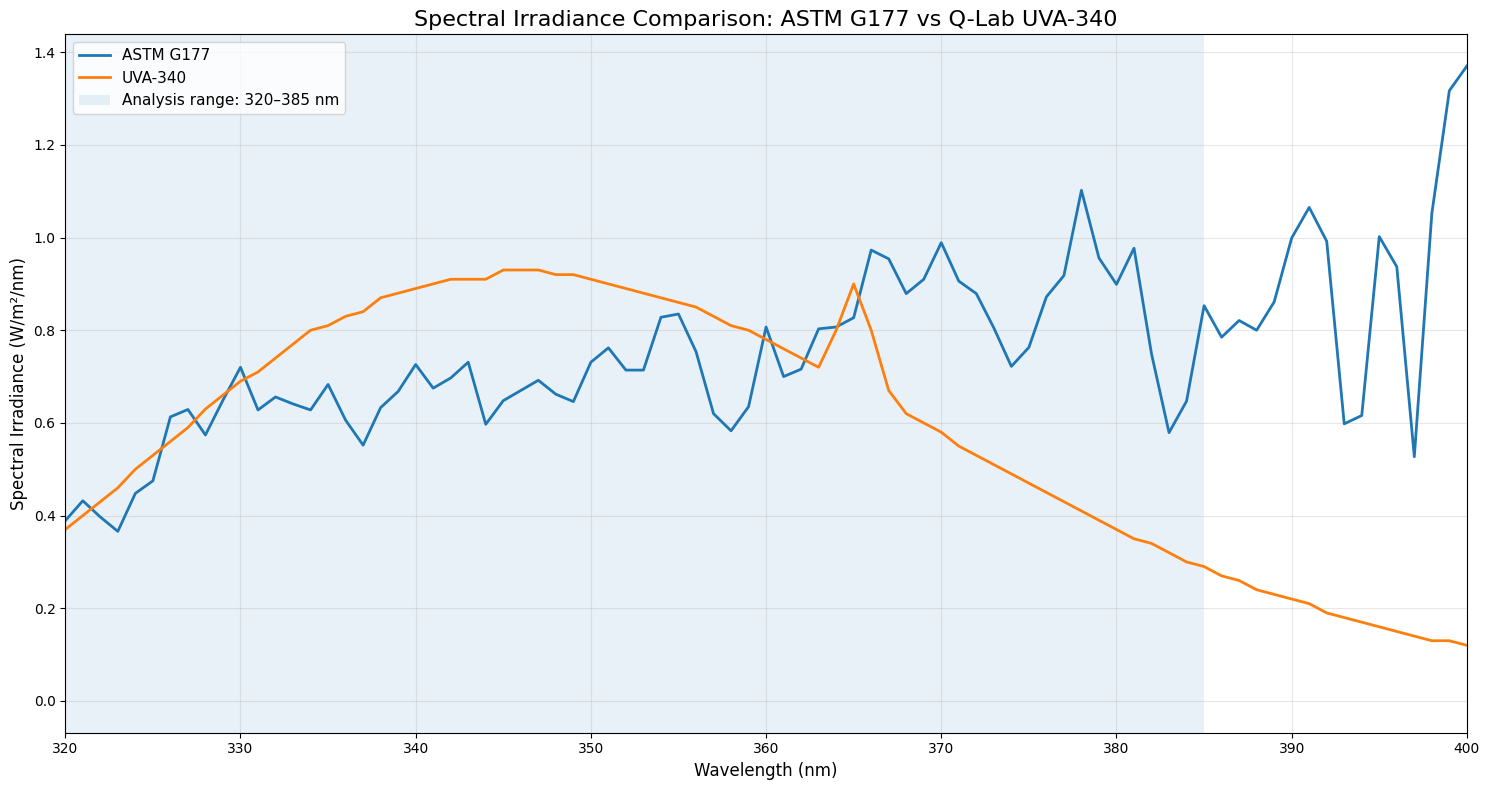

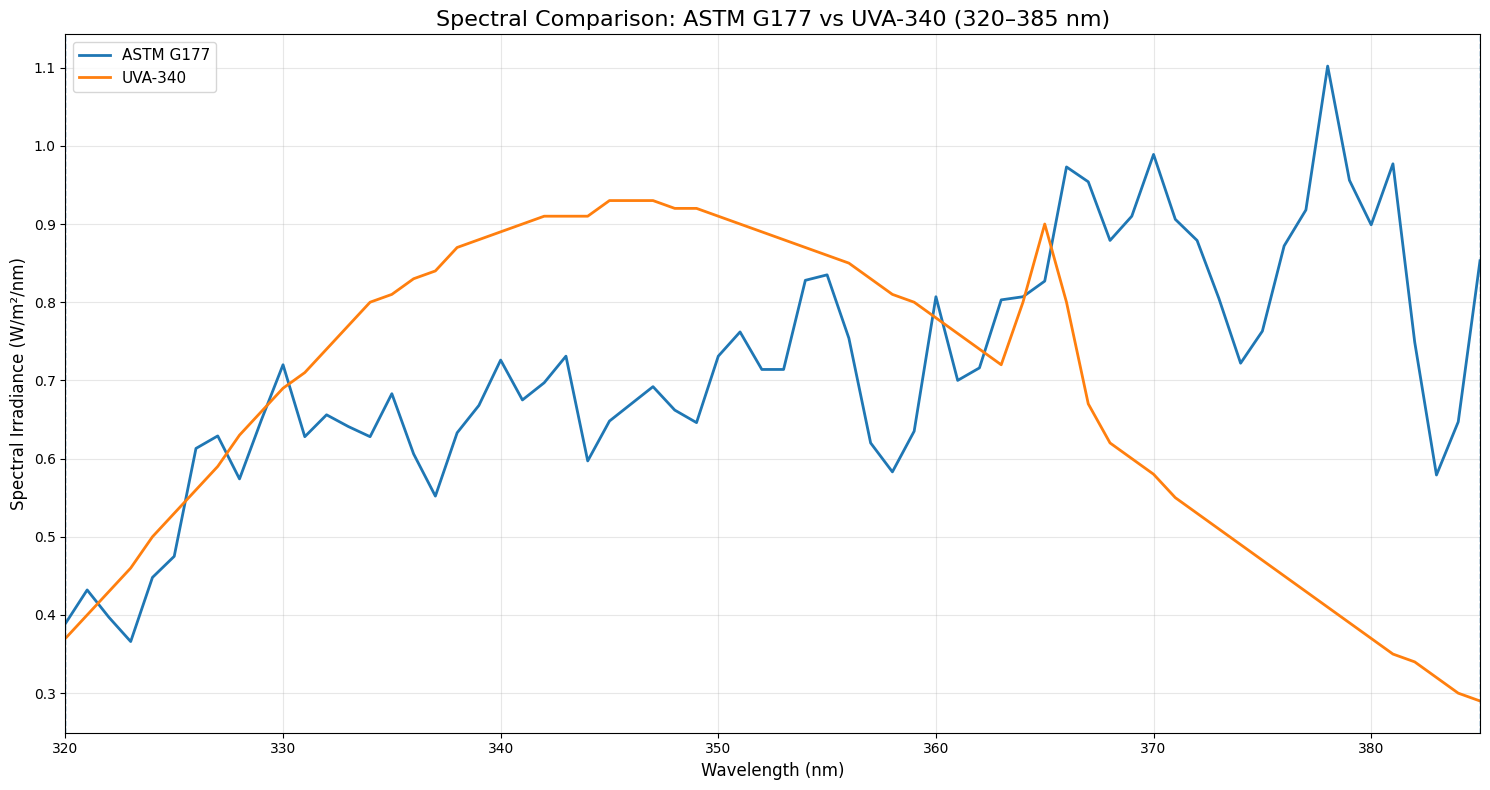

Heatmap data added to Excel.


In [16]:
# ============================================================
# ASTM G177 vs UVA-340
# SPECTRAL COMPARISON ANALYSIS
#
# Outputs:
#   1. Summary table
#   2. R, SD, Pearson, R², Spearman comparison charts
#   3. Chi-Square Sum chart
#   4. Spectral comparison chart
#   5. Excel file
#   6. CSV file
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr


# ============================================================
# 1. FILE PATH
# ============================================================

file_path = (
    '/content/drive/MyDrive/'
    'Python_study/datasets/'
    'spectral_data.csv'
)


# ============================================================
# 2. READ DATA
# ============================================================

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()


print("=" * 100)
print("ASTM G177 vs UVA-340 SPECTRAL COMPARISON")
print("=" * 100)

print("\nColumns:")
print(df.columns.tolist())

print("\nInitial data:")
print(df.head())


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Wavelength_nm",
    "I_G177",
    "I_UVA340"
]


missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ============================================================
# 4. CONVERT TO NUMERIC
# ============================================================

for col in required_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 5. CLEAN DATA
# ============================================================

df = df.dropna(
    subset=required_columns
).copy()


# G177 must be > 0
df = df[
    df["I_G177"] > 0
].copy()


# Sort
df = df.sort_values(
    "Wavelength_nm"
)


# Remove duplicate wavelength
df = df.groupby(
    "Wavelength_nm",
    as_index=False
)[
    ["I_G177", "I_UVA340"]
].mean()


# ============================================================
# 6. WAVELENGTH RANGES
# ============================================================

lambda_min = 320

lambda_max_list = [
    330,
    340,
    350,
    360,
    370,
    380,
    385
]


# ============================================================
# 7. CALCULATION
# ============================================================

results = []

calculation_details = {}


for lambda_max in lambda_max_list:

    # --------------------------------------------------------
    # Select wavelength range
    # --------------------------------------------------------

    df_range = df[
        (df["Wavelength_nm"] >= lambda_min)
        &
        (df["Wavelength_nm"] <= lambda_max)
    ].copy()


    # --------------------------------------------------------
    # Check number of points
    # --------------------------------------------------------

    if len(df_range) < 2:

        print(
            f"WARNING: Not enough data for "
            f"{lambda_min}-{lambda_max} nm"
        )

        continue


    # --------------------------------------------------------
    # Difference
    # --------------------------------------------------------

    df_range["Difference"] = (
        df_range["I_G177"]
        -
        df_range["I_UVA340"]
    )


    # --------------------------------------------------------
    # Squared Difference
    # --------------------------------------------------------

    df_range["Squared_Difference"] = (
        df_range["Difference"] ** 2
    )


    # --------------------------------------------------------
    # Chi-Square Term
    #
    # (G177 - UVA340)^2 / G177
    # --------------------------------------------------------

    df_range["Chi_Square_Term"] = (

        df_range["Squared_Difference"]
        /
        df_range["I_G177"]

    )


    # --------------------------------------------------------
    # Chi-Square Sum
    # --------------------------------------------------------

    chi_square_sum = (
        df_range["Chi_Square_Term"].sum()
    )


    # --------------------------------------------------------
    # Denominator
    #
    # EXACTLY according to user's formula:
    #
    # x - 320
    # --------------------------------------------------------

    denominator = (
        lambda_max
        -
        lambda_min
    )


    # --------------------------------------------------------
    # Standard Deviation
    # --------------------------------------------------------

    SD = np.sqrt(
        chi_square_sum
        /
        denominator
    )


    # --------------------------------------------------------
    # Spectral Similarity Coefficient R
    #
    # R = 1 - SD
    # --------------------------------------------------------

    R = 1 - SD


    # ========================================================
    # PEARSON
    # ========================================================

    Pearson, Pearson_p = pearsonr(
        df_range["I_G177"],
        df_range["I_UVA340"]
    )


    # ========================================================
    # SPEARMAN
    # ========================================================

    Spearman, Spearman_p = spearmanr(
        df_range["I_G177"],
        df_range["I_UVA340"]
    )


    # ========================================================
    # R²
    #
    # R² = Pearson²
    # ========================================================

    R_squared = Pearson ** 2


    # ========================================================
    # SAVE RESULT
    # ========================================================

    results.append({

        "Range_nm":
            f"{lambda_min}-{lambda_max}",

        "Lambda_Min_nm":
            lambda_min,

        "Lambda_Max_nm":
            lambda_max,

        "N":
            len(df_range),

        "Chi_Square_Sum":
            chi_square_sum,

        "SD":
            SD,

        "R":
            R,

        "Pearson":
            Pearson,

        "Pearson_p":
            Pearson_p,

        "R_squared":
            R_squared,

        "Spearman":
            Spearman,

        "Spearman_p":
            Spearman_p

    })


    # --------------------------------------------------------
    # Save detailed calculation
    # --------------------------------------------------------

    calculation_details[
        f"{lambda_min}-{lambda_max}"
    ] = df_range.copy()


# ============================================================
# 8. CREATE SUMMARY DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 9. SORT BY R DESCENDING
# ============================================================

results_df = results_df.sort_values(
    by="R",
    ascending=False
).reset_index(
    drop=True
)


# ============================================================
# 10. DISPLAY TABLE
# ============================================================

results_display = results_df.copy()


numeric_columns = [
    "Chi_Square_Sum",
    "SD",
    "R",
    "Pearson",
    "Pearson_p",
    "R_squared",
    "Spearman",
    "Spearman_p"
]


for col in numeric_columns:

    results_display[col] = (
        results_display[col].round(6)
    )


print("\n")
print("=" * 130)
print("SUMMARY COMPARISON TABLE")
print("=" * 130)


print(
    results_display[
        [
            "Range_nm",
            "N",
            "Chi_Square_Sum",
            "SD",
            "R",
            "R_squared",
            "Pearson",
            "Spearman"
        ]
    ].to_string(index=False)
)


# ============================================================
# 11. CHART 1
# R COMPARISON
# ============================================================

plot_df = results_df.sort_values(
    "Lambda_Max_nm"
)


plt.figure(
    figsize=(12, 6)
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["R"],
    marker="o",
    linewidth=2
)


plt.axhline(
    y=0.90,
    linestyle="--",
    linewidth=1.5,
    label="Reference: R = 0.90"
)


plt.xlabel(
    "Wavelength Range"
)

plt.ylabel(
    "Spectral Similarity Coefficient (R)"
)

plt.title(
    "ASTM G177 vs UVA-340: R by Wavelength Range"
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. CHART 2
# R², PEARSON AND SPEARMAN
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["Pearson"],
    marker="o",
    linewidth=2,
    label="Pearson r"
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["R_squared"],
    marker="s",
    linewidth=2,
    label="R²"
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["Spearman"],
    marker="^",
    linewidth=2,
    label="Spearman ρ"
)


plt.axhline(
    y=0.90,
    linestyle="--",
    linewidth=1.5,
    label="Reference = 0.90"
)


plt.xlabel(
    "Wavelength Range"
)

plt.ylabel(
    "Correlation Coefficient"
)

plt.title(
    "Correlation Comparison: G177 vs UVA-340"
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. CHART 3
# SD COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["SD"],
    marker="o",
    linewidth=2
)


plt.xlabel(
    "Wavelength Range"
)

plt.ylabel(
    "Standard Deviation (SD)"
)

plt.title(
    "Standard Deviation by Wavelength Range"
)


plt.grid(
    True,
    alpha=0.3
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. CHART 4
# CHI-SQUARE SUM
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    plot_df["Range_nm"],
    plot_df["Chi_Square_Sum"],
    marker="o",
    linewidth=2
)


plt.xlabel(
    "Wavelength Range"
)

plt.ylabel(
    "Chi-Square Sum"
)

plt.title(
    "Chi-Square Sum by Wavelength Range"
)


plt.grid(
    True,
    alpha=0.3
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. CHART 5
# G177 vs UVA-340 SPECTRAL CURVES
# ============================================================

plt.figure(
    figsize=(14, 7)
)


plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    linewidth=2,
    label="ASTM G177"
)


plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    linewidth=2,
    label="UVA-340"
)


plt.xlabel(
    "Wavelength (nm)"
)

plt.ylabel(
    "Spectral Irradiance (W/m²/nm)"
)

plt.title(
    "Spectral Comparison: ASTM G177 vs UVA-340"
)


plt.xlim(
    280,
    400
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 16. CHART 6
# RANKING OF WAVELENGTH RANGES
# ============================================================

ranking_df = results_df.sort_values(
    by="R",
    ascending=False
)


plt.figure(
    figsize=(12, 7)
)


plt.barh(
    ranking_df["Range_nm"],
    ranking_df["R"]
)


plt.xlabel(
    "Spectral Similarity Coefficient (R)"
)

plt.ylabel(
    "Wavelength Range"
)

plt.title(
    "Ranking of Wavelength Ranges by R"
)


plt.axvline(
    x=0.90,
    linestyle="--",
    linewidth=1.5,
    label="Reference: R = 0.90"
)


plt.legend()

plt.grid(
    axis="x",
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# 17. EXPORT CSV
# ============================================================

output_csv = (
    "/content/drive/MyDrive/"
    "Python_study/datasets/"
    "G177_UVA340_Comparison_Results.csv"
)


results_display.to_csv(
    output_csv,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. EXPORT EXCEL
# ============================================================

output_excel = (
    "/content/drive/MyDrive/"
    "Python_study/datasets/"
    "G177_UVA340_Comparison_Results.xlsx"
)


with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:


    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    results_display.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )


    # --------------------------------------------------------
    # DETAILED CALCULATIONS
    # --------------------------------------------------------

    for range_name, detail_df in calculation_details.items():

        sheet_name = (
            "Detail_"
            +
            range_name.replace("-", "_")
            +
            "nm"
        )

        detail_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )


    # --------------------------------------------------------
    # FORMAT EXCEL
    # --------------------------------------------------------

    workbook = writer.book


    for worksheet in workbook.worksheets:

        worksheet.freeze_panes = "A2"


        for column_cells in worksheet.columns:

            max_length = 0

            column_letter = (
                column_cells[0].column_letter
            )


            for cell in column_cells:

                try:

                    cell_length = len(
                        str(cell.value)
                    )

                    max_length = max(
                        max_length,
                        cell_length
                    )

                except:

                    pass


            worksheet.column_dimensions[
                column_letter
            ].width = min(
                max_length + 2,
                30
            )


# ============================================================
# 19. FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 100)
print("ANALYSIS COMPLETED")
print("=" * 100)

print(
    f"\nCSV:\n{output_csv}"
)

print(
    f"\nExcel:\n{output_excel}"
)

print(
    "\nNumber of wavelength ranges:",
    len(results_df)
)

# ============================================================
# 20. HEATMAP 10 × 5
#
# Rows    = wavelength ranges
# Columns = R, R², SD, Pearson, Chi-Square Sum
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Create heatmap data
# ------------------------------------------------------------

heatmap_df = results_df.sort_values(
    "Lambda_Max_nm"
).copy()


heatmap_df = heatmap_df[
    [
        "Range_nm",
        "R",
        "R_squared",
        "SD",
        "Pearson",
        "Chi_Square_Sum"
    ]
].set_index(
    "Range_nm"
)


# ------------------------------------------------------------
# Normalize each column separately
#
# This is important because:
# R, R², SD and Chi-Square have different scales.
# ------------------------------------------------------------

heatmap_normalized = heatmap_df.copy()


for col in heatmap_normalized.columns:

    col_min = heatmap_normalized[col].min()
    col_max = heatmap_normalized[col].max()

    if col_max != col_min:

        heatmap_normalized[col] = (
            heatmap_normalized[col] - col_min
        ) / (
            col_max - col_min
        )

    else:

        heatmap_normalized[col] = 1


# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 8)
)


im = ax.imshow(
    heatmap_normalized.values,
    aspect="auto"
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(
        len(heatmap_normalized.columns)
    )
)

ax.set_xticklabels(
    [
        "R",
        "R²",
        "SD",
        "Pearson",
        "Chi-Square Sum"
    ],
    fontsize=11
)


ax.set_yticks(
    np.arange(
        len(heatmap_normalized.index)
    )
)

ax.set_yticklabels(
    heatmap_normalized.index,
    fontsize=11
)


# ------------------------------------------------------------
# Display original values inside cells
# ------------------------------------------------------------

for i in range(
    len(heatmap_normalized.index)
):

    for j in range(
        len(heatmap_normalized.columns)
    ):

        original_value = (
            heatmap_df.iloc[i, j]
        )

        ax.text(
            j,
            i,
            f"{original_value:.3f}",
            ha="center",
            va="center",
            fontsize=9
        )


# ------------------------------------------------------------
# Titles
# ------------------------------------------------------------

ax.set_title(
    "Heatmap of Spectral Comparison Results",
    fontsize=15,
    pad=15
)

ax.set_xlabel(
    "Statistical and Spectral Similarity Metrics",
    fontsize=11
)

ax.set_ylabel(
    "Wavelength Range",
    fontsize=11
)


# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Normalized Value",
    fontsize=10
)


plt.tight_layout()

plt.show()

# ============================================================
# 21. FULL SPECTRAL PLOT
# ASTM G177 vs UVA-340
# 320–400 nm
# ============================================================

plt.figure(
    figsize=(15, 8)
)


# ------------------------------------------------------------
# ASTM G177
# ------------------------------------------------------------

plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    linewidth=2,
    label="ASTM G177"
)


# ------------------------------------------------------------
# UVA-340
# ------------------------------------------------------------

plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    linewidth=2,
    label="UVA-340"
)


# ------------------------------------------------------------
# Highlight analysis region
# ------------------------------------------------------------

plt.axvspan(
    320,
    385,
    alpha=0.10,
    label="Analysis range: 320–385 nm"
)


# ------------------------------------------------------------
# Axis
# ------------------------------------------------------------

plt.xlabel(
    "Wavelength (nm)",
    fontsize=12
)

plt.ylabel(
    "Spectral Irradiance (W/m²/nm)",
    fontsize=12
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(
    "Spectral Irradiance Comparison: "
    "ASTM G177 vs Q-Lab UVA-340",
    fontsize=16
)


# ------------------------------------------------------------
# X-axis
# ------------------------------------------------------------

plt.xlim(
    320,
    400
)


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

plt.grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

plt.legend(
    fontsize=11
)


plt.tight_layout()

plt.show()

# ============================================================
# 22. ZOOMED SPECTRAL PLOT
# 320–385 nm
# ============================================================

df_zoom = df[
    (df["Wavelength_nm"] >= 320)
    &
    (df["Wavelength_nm"] <= 385)
].copy()


plt.figure(
    figsize=(15, 8)
)


plt.plot(
    df_zoom["Wavelength_nm"],
    df_zoom["I_G177"],
    linewidth=2,
    label="ASTM G177"
)


plt.plot(
    df_zoom["Wavelength_nm"],
    df_zoom["I_UVA340"],
    linewidth=2,
    label="UVA-340"
)


# ------------------------------------------------------------
# Mark range boundaries
# ------------------------------------------------------------

plt.axvline(
    320,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    385,
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    "Wavelength (nm)",
    fontsize=12
)

plt.ylabel(
    "Spectral Irradiance (W/m²/nm)",
    fontsize=12
)


plt.title(
    "Spectral Comparison: ASTM G177 vs UVA-340 "
    "(320–385 nm)",
    fontsize=16
)


plt.xlim(
    320,
    385
)


plt.grid(
    True,
    alpha=0.3
)


plt.legend(
    fontsize=11
)


plt.tight_layout()

plt.show()

# ============================================================
# 23. EXPORT HEATMAP DATA TO EXCEL
# ============================================================

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    # Raw values
    heatmap_df.to_excel(
        writer,
        sheet_name="Heatmap_Data"
    )

    # Normalized values
    heatmap_normalized.to_excel(
        writer,
        sheet_name="Heatmap_Normalized"
    )


print(
    "Heatmap data added to Excel."
)

#BẢNG SO SÁNH KẾT QUẢ TỔNG HỢP



STANDARDIZED DATA
   Wavelength_nm  I_UVA340    I_AM15
0            295      0.00  0.000012
1            296      0.01  0.000048
2            297      0.01  0.000097
3            298      0.01  0.000290
4            299      0.01  0.000492
5            300      0.01  0.001020
6            301      0.02  0.001930
7            302      0.03  0.002921
8            303      0.03  0.007095
9            304      0.04  0.009470

Total wavelength points:
66

Wavelength range:
295.0 - 360.0 nm

CALCULATING 295-300 nm

CALCULATING 295-310 nm

CALCULATING 295-320 nm

CALCULATING 295-330 nm

CALCULATING 295-340 nm

CALCULATING 295-350 nm

CALCULATING 295-360 nm

CALCULATING 295-370 nm

CALCULATING 295-380 nm

CALCULATING 295-385 nm



SELECTION MATRIX
Wavelength_Range  Spectral_R R > 0.90  Pearson_r Pearson r > 0.90  Spearman_rho Spearman ρ > 0.90  R_squared R² > 0.90 All 4 Conditions
      295-300 nm    0.143414       NO   0.400360               NO      0.654654                NO   0.160288    

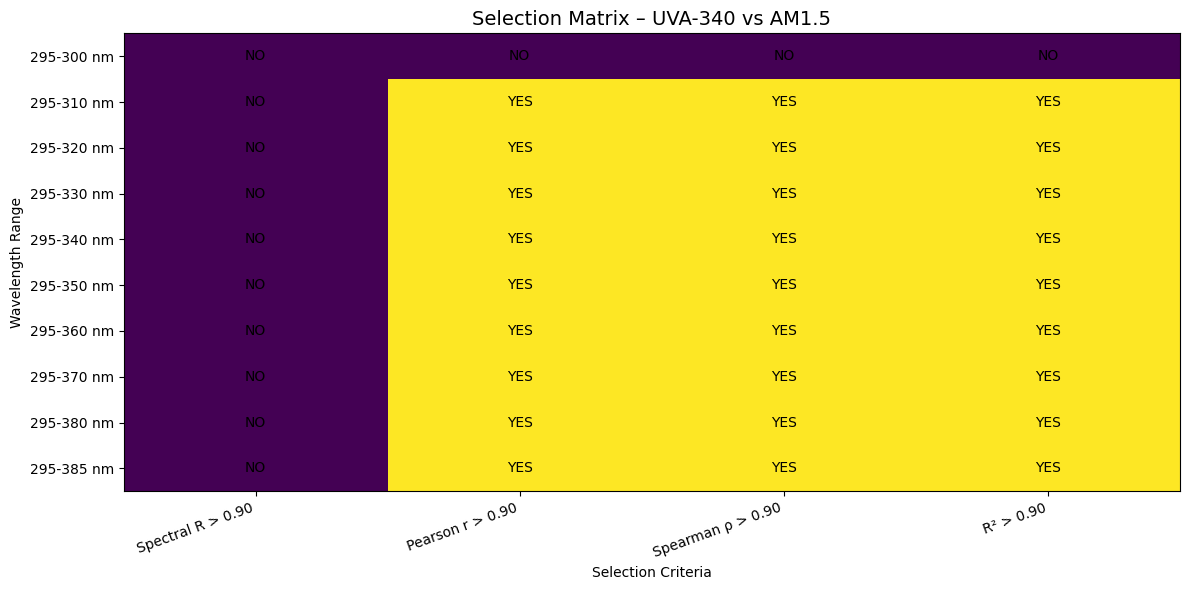




FINAL SELECTION SUMMARY
Không có dải phổ nào thỏa cả 4 điều kiện.


Bạn có thể xem xét các dải trong bảng Selection Matrix trước khi lựa chọn dải cuối cùng.


In [ ]:
# ============================================================
# STANDARDIZED SPECTRAL COMPARISON
#
# Q-Lab UVA-340
#        VS
# ASTM G173-03 AM1.5 Global
#
# Metrics:
#   1. Spectral Similarity R
#   2. Pearson r
#   3. Spearman rho
#   4. R²
#
# Wavelength ranges: từ 295nm đến 385nm
# Main purpose:
#   Identify wavelength range suitable for subsequent
#   spectral correlation analysis.
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT
# ============================================================

# Nếu Colab báo thiếu pvlib, chạy dòng dưới một lần:
!pip install pvlib openpyxl scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib

from scipy.stats import pearsonr
from scipy.stats import spearmanr


# ============================================================
# 1. Q-LAB UVA-340 FILE
# ============================================================

uva_file = (
    "/content/drive/MyDrive/Python_study/"
    "datasets/UVA340_QLab.csv"
)


# ============================================================
# 2. READ UVA-340 DATA
# ============================================================

uva = pd.read_csv(
    uva_file
)

uva.columns = (
    uva.columns
    .str.strip()
)


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Wavelength_nm",
    "I_UVA340"
]

missing_columns = [
    col
    for col in required_columns
    if col not in uva.columns
]

if missing_columns:

    raise ValueError(
        "Thiếu các cột: "
        + str(missing_columns)
    )


# ============================================================
# 4. CONVERT DATA TO NUMERIC
# ============================================================

uva["Wavelength_nm"] = pd.to_numeric(
    uva["Wavelength_nm"],
    errors="coerce"
)

uva["I_UVA340"] = pd.to_numeric(
    uva["I_UVA340"],
    errors="coerce"
)


# ============================================================
# 5. REMOVE INVALID DATA
# ============================================================

uva = uva.dropna(
    subset=[
        "Wavelength_nm",
        "I_UVA340"
    ]
).copy()


# ============================================================
# 6. SORT WAVELENGTH
# ============================================================

uva = uva.sort_values(
    "Wavelength_nm"
)


# ============================================================
# 7. REMOVE DUPLICATE WAVELENGTHS
# ============================================================

uva = uva.groupby(
    "Wavelength_nm",
    as_index=False
)["I_UVA340"].mean()


# ============================================================
# 8. ANALYSIS WAVELENGTH
# ============================================================

lambda_min = 295

lambda_max_list = [
    300,
    310,
    320,
    330,
    340,
    350,
    360,
    370,
    380,
    385
]


# ============================================================
# 9. GET ASTM G173-03 AM1.5
# ============================================================

am15_all = (
    pvlib.spectrum.get_reference_spectra(
        standard="ASTM G173-03"
    )
)


# ============================================================
# 10. SELECT AM1.5 GLOBAL
# ============================================================

am15_global = (
    am15_all["global"]
)


# ============================================================
# 11. LIMIT UVA DATA
# ============================================================

uva = uva[
    (
        uva["Wavelength_nm"]
        >= lambda_min
    )
    &
    (
        uva["Wavelength_nm"]
        <= max(lambda_max_list)
    )
].copy()


# ============================================================
# 12. INTERPOLATE AM1.5
#     TO UVA-340 WAVELENGTH GRID
# ============================================================

am15_interp = np.interp(
    uva["Wavelength_nm"].values,
    am15_all.index.values,
    am15_global.values
)


# ============================================================
# 13. CREATE STANDARDIZED DATASET
# ============================================================

spectra = pd.DataFrame({

    "Wavelength_nm":
        uva["Wavelength_nm"].values,

    "I_UVA340":
        uva["I_UVA340"].values,

    "I_AM15":
        am15_interp

})


# ============================================================
# 14. BASIC CHECK
# ============================================================

print("\n")
print("=" * 90)
print("STANDARDIZED DATA")
print("=" * 90)

print(
    spectra.head(10)
)

print("\nTotal wavelength points:")
print(
    len(spectra)
)

print("\nWavelength range:")
print(
    f"{spectra['Wavelength_nm'].min():.1f}"
    f" - "
    f"{spectra['Wavelength_nm'].max():.1f} nm"
)

# ============================================================
# 15. TÍNH R, PEARSON R, SPEARMAN RHO, R^2 CHO TỪNG KHOẢNG
# ============================================================

results = []

calculation_details = {}


for lambda_max in lambda_max_list:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"CALCULATING {lambda_min}-{lambda_max} nm"
    )

    print(
        "=" * 70
    )


    # --------------------------------------------------------
    # Lọc khoảng wavelength
    # --------------------------------------------------------

    df_range = spectra[
        (
            spectra["Wavelength_nm"]
            >= lambda_min
        )
        &
        (
            spectra["Wavelength_nm"]
            <= lambda_max
        )
    ].copy()


    # --------------------------------------------------------
    # Kiểm tra
    # --------------------------------------------------------

    if len(df_range) < 2:

        print(
            "Không đủ dữ liệu."
        )

        continue


    # --------------------------------------------------------
    # Loại bỏ AM1.5 <= 0
    #
    # Tránh chia cho 0
    # --------------------------------------------------------

    df_range = df_range[
        df_range["I_AM15"] > 0
    ].copy()


    # Đảm bảo vẫn còn dữ liệu sau khi lọc
    if len(df_range) < 2:
        print(f"Không đủ dữ liệu sau khi loại bỏ I_AM15 <= 0 cho {lambda_min}-{lambda_max} nm.")
        continue


    # --------------------------------------------------------
    # Difference
    #
    # AM1.5 - UVA340
    # --------------------------------------------------------

    df_range["Difference"] = (
        df_range["I_AM15"]
        -
        df_range["I_UVA340"]
    )


    # --------------------------------------------------------
    # Squared Difference
    # --------------------------------------------------------

    df_range[
        "Squared_Difference"
    ] = (
        df_range["Difference"] ** 2
    )


    # --------------------------------------------------------
    # Chi-square term
    #
    # Theo công thức:
    #
    # (AM1.5 - UVA340)^2 / AM1.5
    #
    # --------------------------------------------------------

    df_range[
        "Chi_Square_Term"
    ] = (
        df_range["Squared_Difference"]
        /
        df_range["I_AM15"]
    )


    # --------------------------------------------------------
    # Tổng Chi-square
    # --------------------------------------------------------

    chi_square_sum = (
        df_range[
            "Chi_Square_Term"
        ].sum()
    )


    # --------------------------------------------------------
    # Denominator
    # --------------------------------------------------------

    denominator = (
        lambda_max
        -
        lambda_min
    )

    # Tránh chia cho 0
    if denominator == 0:
        print(f"WARNING: Mẫu số bằng 0 cho {lambda_min}-{lambda_max} nm. Không thể tính Standard Deviation và Spectral_R.")
        standard_deviation = np.nan
        R = np.nan
    else:
        # --------------------------------------------------------
        # Standard deviation
        # --------------------------------------------------------

        standard_deviation = np.sqrt(
            chi_square_sum
            /
            denominator
        )


        # --------------------------------------------------------
        # Spectral Similarity R
        # --------------------------------------------------------

        R = (
            1
            -
            standard_deviation
        )

    # --------------------------------------------------------
    # Calculate Pearson, Spearman, and R-squared
    # --------------------------------------------------------
    if len(df_range) > 1:
        pearson_r, pearson_p = pearsonr(df_range["I_AM15"], df_range["I_UVA340"])
        spearman_rho, spearman_p = spearmanr(df_range["I_AM15"], df_range["I_UVA340"])
        R_squared = pearson_r**2
    else:
        pearson_r, pearson_p = np.nan, np.nan
        spearman_rho, spearman_p = np.nan, np.nan
        R_squared = np.nan


    # --------------------------------------------------------
    # Lưu kết quả
    # --------------------------------------------------------

    results.append({

        "Wavelength_Range":
            f"{lambda_min}-{lambda_max} nm",

        "Lambda_Min_nm":
            lambda_min,

        "Lambda_Max_nm":
            lambda_max,

        "Number_of_Data_Points":
            len(df_range),

        "Chi_Square_Sum":
            chi_square_sum,

        "Standard_Deviation":
            standard_deviation,

        "Spectral_R": # Changed 'R' to 'Spectral_R' here
            R,
        "Pearson_r":
            pearson_r,
        "Pearson_p":
            pearson_p,
        "Spearman_rho":
            spearman_rho,
        "Spearman_p":
            spearman_p,
        "R_squared":
            R_squared
    })


    # --------------------------------------------------------
    # Lưu chi tiết
    # --------------------------------------------------------

    calculation_details[
        f"{lambda_min}-{lambda_max}"
    ] = df_range.copy()


# ============================================================
# 16. TẠO BẢNG TỔNG HỢP
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 17. DEFINE THE 4 SELECTION CONDITIONS
# ============================================================

# Condition 1:
# Spectral similarity R > 0.90

results_df["Condition_R"] = (
    results_df["Spectral_R"] > 0.90
)


# Condition 2:
# Pearson r > 0.90

results_df["Condition_Pearson"] = (
    results_df["Pearson_r"] > 0.90
)


# Condition 3:
# Spearman rho > 0.90

results_df["Condition_Spearman"] = (
    results_df["Spearman_rho"] > 0.90
)


# Condition 4:
# R² > 0.90

results_df["Condition_R2"] = (
    results_df["R_squared"] > 0.90
)


# ============================================================
# 18. CREATE YES / NO COLUMNS
# ============================================================

results_df["R > 0.90"] = np.where(
    results_df["Condition_R"],
    "YES",
    "NO"
)


results_df["Pearson r > 0.90"] = np.where(
    results_df["Condition_Pearson"],
    "YES",
    "NO"
)


results_df["Spearman ρ > 0.90"] = np.where(
    results_df["Condition_Spearman"],
    "YES",
    "NO"
)


results_df["R² > 0.90"] = np.where(
    results_df["Condition_R2"],
    "YES",
    "NO"
)


# ============================================================
# 19. ALL FOUR CONDITIONS
# ============================================================

results_df["All_4_Conditions"] = (
    results_df["Condition_R"]
    &
    results_df["Condition_Pearson"]
    &
    results_df["Condition_Spearman"]
    &
    results_df["Condition_R2"]
)


results_df["All 4 Conditions"] = np.where(
    results_df["All_4_Conditions"],
    "YES",
    "NO"
)


# ============================================================
# 20. SORT BY WAVELENGTH
# ============================================================

results_by_wavelength = (
    results_df
    .sort_values(
        "Lambda_Max_nm"
    )
    .reset_index(drop=True)
)


# ============================================================
# 21. CREATE SELECTION MATRIX
# ============================================================

selection_matrix = results_by_wavelength[
    [
        "Wavelength_Range",

        "Spectral_R",
        "R > 0.90",

        "Pearson_r",
        "Pearson r > 0.90",

        "Spearman_rho",
        "Spearman ρ > 0.90",

        "R_squared",
        "R² > 0.90",

        "All 4 Conditions"
    ]
].copy()


# ============================================================
# 22. DISPLAY SELECTION MATRIX
# ============================================================

print("\n\n")

print("=" * 130)

print(
    "SELECTION MATRIX"
)

print("=" * 130)


print(
    selection_matrix.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}"
    )
)


# ============================================================
# 23. IDENTIFY RANGES PASSING ALL 4 CONDITIONS
# ============================================================

qualified_all = results_by_wavelength[
    results_by_wavelength[
        "All_4_Conditions"
    ]
].copy()


# ============================================================
# 24. DISPLAY QUALIFIED RANGES
# ============================================================

print("\n\n")

print("=" * 100)

print(
    "WAVELENGTH RANGES PASSING ALL 4 CONDITIONS"
)

print("=" * 100)


if len(qualified_all) > 0:

    print(
        qualified_all[
            [
                "Wavelength_Range",
                "Spectral_R",
                "Pearson_r",
                "Spearman_rho",
                "R_squared"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
            f"{x:.8f}"
        )
    )

else:

    print(
        "Không có dải phổ nào "
        "thỏa cả 4 điều kiện."
    )


# ============================================================n# 25. COUNT CONDITIONS PASSED
# ============================================================

results_by_wavelength[
    "Conditions_Passed"
] = (
    results_by_wavelength[
        [
            "Condition_R",
            "Condition_Pearson",
            "Condition_Spearman",
            "Condition_R2"
        ]
    ]
    .sum(axis=1)
)


# ============================================================
# 26. CREATE CONDITION SCORE
# ============================================================

# 4/4 = pass all conditions
# 3/4 = pass three conditions
# 2/4 = pass two conditions
# etc.

results_by_wavelength[
    "Condition_Score"
] = (
    results_by_wavelength[
        "Conditions_Passed"
    ].astype(str)
    +
    "/4"
)


# ============================================================
# 27. CREATE EXTENDED SELECTION MATRIX
# ============================================================

selection_matrix_extended = (
    results_by_wavelength[
        [
            "Wavelength_Range",

            "Spectral_R",
            "R > 0.90",

            "Pearson_r",
            "Pearson r > 0.90",

            "Spearman_rho",
            "Spearman ρ > 0.90",

            "R_squared",
            "R² > 0.90",

            "Conditions_Passed",
            "Condition_Score",

            "All 4 Conditions"
        ]
    ]
    .copy()
)


# ============================================================
# 28. DISPLAY EXTENDED MATRIX
# ============================================================

print("\n\n")

print("=" * 140)

print(
    "EXTENDED SELECTION MATRIX"
)

print("=" * 140)


print(
    selection_matrix_extended.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}"
    )
)


# ============================================================
# 29. SORT BY NUMBER OF CONDITIONS PASSED
# ============================================================

selection_ranked = (
    results_by_wavelength
    .sort_values(
        [
            "Conditions_Passed",
            "Spectral_R",
            "Pearson_r",
            "Spearman_rho"
        ],
        ascending=[
            False,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 30. DISPLAY RANKED CANDIDATES
# ============================================================

print("\n\n")

print("=" * 110)

print(
    "CANDIDATE RANGES SORTED BY CONDITIONS PASSED"
)

print("=" * 110)


print(
    selection_ranked[
        [
            "Wavelength_Range",
            "Conditions_Passed",
            "Condition_Score",
            "Spectral_R",
            "Pearson_r",
            "Spearman_rho",
            "R_squared",
            "All 4 Conditions"
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
        f"{x:.8f}"
    )
)


# ============================================================
# 31. EXPORT SELECTION MATRIX TO CSV
# ============================================================

selection_matrix_extended.to_csv(
    "UVA340_AM15_Selection_Matrix.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 32. EXPORT QUALIFIED RANGES
# ============================================================

qualified_all[
    [
        "Wavelength_Range",
        "Spectral_R",
        "Pearson_r",
        "Pearson_p",
        "Spearman_rho",
        "Spearman_p",
        "R_squared"
    ]
].to_csv(
    "UVA340_AM15_All_4_Conditions_Passed.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 33. EXPORT RANKED CANDIDATES
# ============================================================

selection_ranked[
    [
        "Wavelength_Range",
        "Conditions_Passed",
        "Condition_Score",
        "Spectral_R",
        "Pearson_r",
        "Spearman_rho",
        "R_squared",
        "All 4 Conditions"
    ]
].to_csv(
    "UVA340_AM15_Candidate_Ranges.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 34. CREATE FINAL EXCEL FILE
# ============================================================

excel_file = (
    "UVA340_AM15_SELECTION_MATRIX.xlsx"
)


with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:


    # --------------------------------------------------------
    # Sheet 1
    # All metrics
    # --------------------------------------------------------

    results_by_wavelength.to_excel(
        writer,
        sheet_name="All_Metrics",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 2
    # Selection Matrix
    # --------------------------------------------------------

    selection_matrix_extended.to_excel(
        writer,
        sheet_name="Selection_Matrix",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 3
    # All 4 conditions passed
    # --------------------------------------------------------

    qualified_all[
        [
            "Wavelength_Range",
            "Spectral_R",
            "Pearson_r",
            "Pearson_p",
            "Spearman_rho",
            "Spearman_p",
            "R_squared"
        ]
    ].to_excel(
        writer,
        sheet_name="All_4_Passed",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 4
    # Ranked candidates
    # --------------------------------------------------------

    selection_ranked[
        [
            "Wavelength_Range",
            "Conditions_Passed",
            "Condition_Score",
            "Spectral_R",
            "Pearson_r",
            "Spearman_rho",
            "R_squared",
            "All 4 Conditions"
        ]
    ].to_excel(
        writer,
        sheet_name="Candidate_Ranges",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 5
    # Synchronized spectra
    # --------------------------------------------------------

    spectra.to_excel(
        writer,
        sheet_name="Synchronized_Spectra",
        index=False
    )


    # --------------------------------------------------------
    # Detailed calculations
    # --------------------------------------------------------

    for range_name, detail_df in (
        calculation_details.items() # Corrected detail_results to calculation_details
    ):

        sheet_name = (
            f"{range_name}_nm"
        )

        detail_df.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )


print("\n")
print("=" * 100)

print(
    "EXCEL FILE CREATED"
)

print("=" * 100)

print(
    excel_file
)


# ============================================================
# 35. VISUALIZE SELECTION MATRIX
# ============================================================

# Convert TRUE/FALSE to numeric

matrix_plot = results_by_wavelength[
    [
        "Wavelength_Range",
        "Condition_R",
        "Condition_Pearson",
        "Condition_Spearman",
        "Condition_R2"
    ]
].copy()


matrix_plot[
    "Condition_R"
] = matrix_plot[
    "Condition_R"
].astype(int)


matrix_plot[
    "Condition_Pearson"
] = matrix_plot[
    "Condition_Pearson"
].astype(int)


matrix_plot[
    "Condition_Spearman"
] = matrix_plot[
    "Condition_Spearman"
].astype(int)


matrix_plot[
    "Condition_R2"
] = matrix_plot[
    "Condition_R2"
].astype(int)


# ============================================================
# 36. PLOT CONDITION MATRIX
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.imshow(
    matrix_plot[
        [
            "Condition_R",
            "Condition_Pearson",
            "Condition_Spearman",
            "Condition_R2"
        ]
    ],
    aspect="auto"
)


plt.xticks(
    range(4),
    [
        "Spectral R > 0.90",
        "Pearson r > 0.90",
        "Spearman ρ > 0.90",
        "R² > 0.90"
    ],
    rotation=20,
    ha="right"
)


plt.yticks(
    range(len(matrix_plot)),
    matrix_plot[
        "Wavelength_Range"
    ]
)


# Add YES / NO text

for i in range(
    len(matrix_plot)
):

    for j in range(4):

        value = matrix_plot.iloc[
            i, j + 1
        ]

        text_value = (
            "YES"
            if value == 1
            else
            "NO"
        )

        plt.text(
            j,
            i,
            text_value,
            ha="center",
            va="center",
            fontsize=10
        )


plt.title(
    "Selection Matrix – UVA-340 vs AM1.5",
    fontsize=14
)


plt.xlabel(
    "Selection Criteria"
)

plt.ylabel(
    "Wavelength Range"
)


plt.tight_layout()


plt.savefig(
    "06_Selection_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 37. FINAL MESSAGE
# ============================================================

print("\n\n")

print("=" * 100)

print(
    "FINAL SELECTION SUMMARY"
)

print("=" * 100)


if len(qualified_all) > 0:

    print(
        f"Có {len(qualified_all)} "
        f"dải phổ thỏa cả 4 điều kiện."
    )

    print("\nCác dải này là:")

    for _, row in (
        qualified_all.iterrows()
    ):

        print(
            f"  • {row['Wavelength_Range']}"
        )

else:

    print(
        "Không có dải phổ nào "
        "thỏa cả 4 điều kiện."
    )


print("\n")
print(
    "Bạn có thể xem xét các dải "
    "trong bảng Selection Matrix "
    "trước khi lựa chọn dải cuối cùng."
)



R CALCULATION ACCORDING TO THE SPECIFIED FORMULA
Wavelength_Range  Lambda_Min_nm  Lambda_Max_nm  Data_Points  Chi_Square_Sum  Denominator_x_minus_295  Square_Root_Value          R R > 0.90
      295-300 nm            295            300            6      3.66869380                        5         0.85658552 0.14341448       NO
      295-310 nm            295            310           16      4.68848269                       15         0.55907559 0.44092441       NO
      295-320 nm            295            320           26      5.71073928                       25         0.47794306 0.52205694       NO
      295-330 nm            295            330           36      7.32645682                       35         0.45752305 0.54247695       NO
      295-340 nm            295            340           46     10.76623795                       45         0.48913161 0.51086839       NO
      295-350 nm            295            350           56     14.83072629                       55         

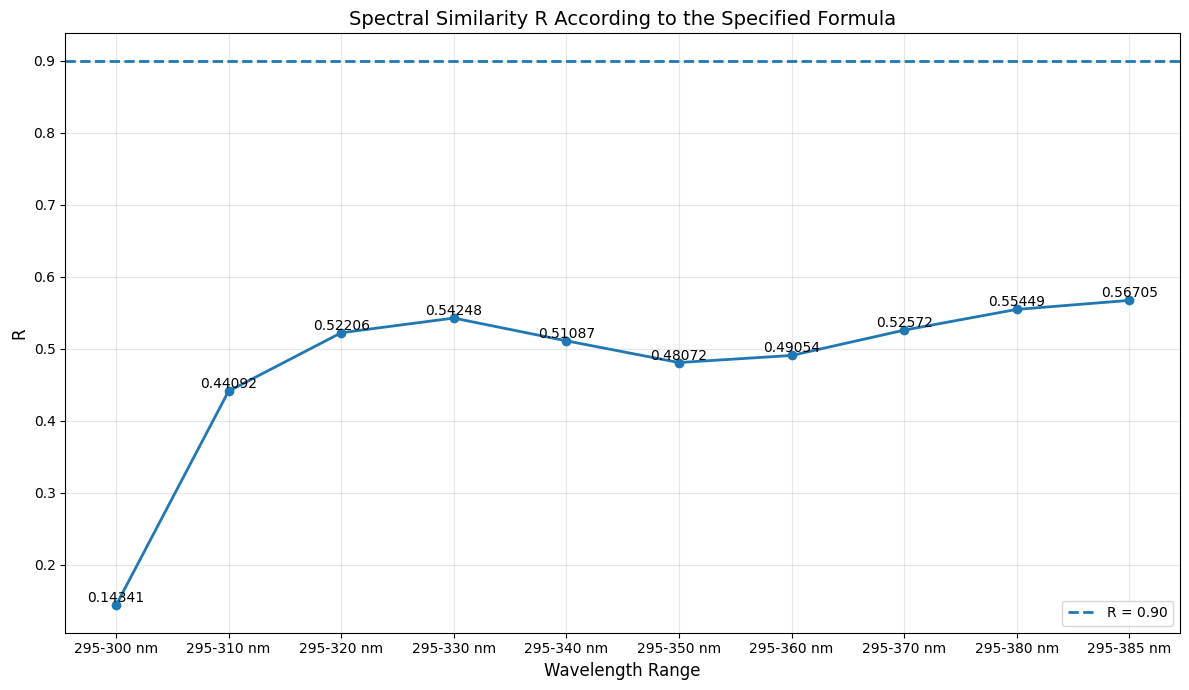




FINAL SUMMARY
     295-300 nm | R = 0.14341448 | R > 0.90: NO
     295-310 nm | R = 0.44092441 | R > 0.90: NO
     295-320 nm | R = 0.52205694 | R > 0.90: NO
     295-330 nm | R = 0.54247695 | R > 0.90: NO
     295-340 nm | R = 0.51086839 | R > 0.90: NO
     295-350 nm | R = 0.48072207 | R > 0.90: NO
     295-360 nm | R = 0.49054342 | R > 0.90: NO
     295-370 nm | R = 0.52572174 | R > 0.90: NO
     295-380 nm | R = 0.55449315 | R > 0.90: NO
     295-385 nm | R = 0.56704516 | R > 0.90: NO

Completed.


In [5]:
# ============================================================
# EXACT R CALCULATION ACCORDING TO THE FORMULA
#
# Formula:
#
# R = 1 - sqrt(
#       Sum[
#           (I_reference - I_UVA340)^2
#           / I_reference
#       ]
#       /
#       (x - 295)
#     )
#
# Reference:
# ASTM G173-03 AM1.5 Global
# from pvlib
#
# UVA-340:
# Q-Lab spectral data
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

!pip install pvlib openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib


# ============================================================
# 2. FILE PATH – Q-LAB UVA-340
# ============================================================

uva_file = (
    "/content/drive/MyDrive/Python_study/"
    "datasets/UVA340_QLab.csv"
)


# ============================================================
# 3. READ Q-LAB UVA-340
# ============================================================

uva = pd.read_csv(
    uva_file
)

uva.columns = (
    uva.columns
    .str.strip()
)


# ============================================================
# 4. CHECK COLUMNS
# ============================================================

required_columns = [
    "Wavelength_nm",
    "I_UVA340"
]

missing = [
    col
    for col in required_columns
    if col not in uva.columns
]

if missing:

    raise ValueError(
        f"Missing columns: {missing}"
    )


# ============================================================
# 5. CONVERT TO NUMERIC
# ============================================================

uva["Wavelength_nm"] = pd.to_numeric(
    uva["Wavelength_nm"],
    errors="coerce"
)

uva["I_UVA340"] = pd.to_numeric(
    uva["I_UVA340"],
    errors="coerce"
)


# ============================================================
# 6. CLEAN DATA
# ============================================================

uva = uva.dropna(
    subset=[
        "Wavelength_nm",
        "I_UVA340"
    ]
).copy()


# Sort
uva = uva.sort_values(
    "Wavelength_nm"
)


# If duplicate wavelength exists,
# calculate mean

uva = uva.groupby(
    "Wavelength_nm",
    as_index=False
)["I_UVA340"].mean()


# ============================================================
# 7. WAVELENGTH SETTINGS
# ============================================================

lambda_min = 295

lambda_max_list = [
    300,
    310,
    320,
    330,
    340,
    350,
    360,
    370,
    380,
    385
]


# ============================================================
# 8. GET ASTM G173-03
# ============================================================

am15 = (
    pvlib.spectrum.get_reference_spectra(
        standard="ASTM G173-03"
    )
)


# ============================================================
# 9. SELECT AM1.5 GLOBAL
# ============================================================

I_AM15_global = (
    am15["global"]
)


# ============================================================
# 10. LIMIT UVA-340 DATA
# ============================================================

uva = uva[
    (
        uva["Wavelength_nm"]
        >= lambda_min
    )
    &
    (
        uva["Wavelength_nm"]
        <= max(lambda_max_list)
    )
].copy()


# ============================================================
# 11. INTERPOLATE AM1.5
#     TO EXACT UVA-340 WAVELENGTHS
# ============================================================

AM15_interp = np.interp(
    uva["Wavelength_nm"].values,
    am15.index.values,
    I_AM15_global.values
)


# ============================================================
# 12. CREATE COMMON DATAFRAME
# ============================================================

spectra = pd.DataFrame({

    "Wavelength_nm":
        uva["Wavelength_nm"].values,

    "I_UVA340":
        uva["I_UVA340"].values,

    "I_AM15":
        AM15_interp

})


# ============================================================
# 13. CALCULATE R
#     EXACTLY ACCORDING TO THE FORMULA
# ============================================================

results = []

detail_results = {}


for x in lambda_max_list:


    # --------------------------------------------------------
    # Select wavelength 295 → x
    # --------------------------------------------------------

    df_range = spectra[
        (
            spectra["Wavelength_nm"]
            >= lambda_min
        )
        &
        (
            spectra["Wavelength_nm"]
            <= x
        )
    ].copy()


    # --------------------------------------------------------
    # Remove AM1.5 <= 0
    # --------------------------------------------------------

    df_range = df_range[
        df_range["I_AM15"] > 0
    ].copy()


    if len(df_range) < 2:

        print(
            f"Not enough data for "
            f"{lambda_min}-{x} nm"
        )

        continue


    # ========================================================
    # FORMULA:
    #
    # (I_AM15 - I_UVA340)^2 / I_AM15
    # ========================================================

    df_range["Difference"] = (
        df_range["I_AM15"]
        -
        df_range["I_UVA340"]
    )


    df_range["Squared_Difference"] = (
        df_range["Difference"] ** 2
    )


    df_range["Chi_Square_Term"] = (
        df_range["Squared_Difference"]
        /
        df_range["I_AM15"]
    )


    # ========================================================
    # SUM
    #
    # Σ [(I_AM15 - I_UVA340)^2 / I_AM15]
    # ========================================================

    chi_square_sum = (
        df_range[
            "Chi_Square_Term"
        ].sum()
    )


    # ========================================================
    # DENOMINATOR
    #
    # x - 295
    #
    # IMPORTANT:
    # This follows the formula exactly.
    # ========================================================

    denominator = (
        x - lambda_min
    )


    # ========================================================
    # VALUE INSIDE SQRT
    # ========================================================

    sqrt_argument = (
        chi_square_sum
        /
        denominator
    )


    # ========================================================
    # SQUARE ROOT
    # ========================================================

    standard_deviation = np.sqrt(
        sqrt_argument
    )


    # ========================================================
    # R
    #
    # R = 1 - sqrt(...)
    # ========================================================

    R = (
        1
        -
        standard_deviation
    )


    # ========================================================
    # R > 0.90
    # ========================================================

    if R > 0.90:

        threshold = "YES"

    else:

        threshold = "NO"


    # ========================================================
    # SAVE RESULT
    # ========================================================

    results.append({

        "Wavelength_Range":
            f"{lambda_min}-{x} nm",

        "Lambda_Min_nm":
            lambda_min,

        "Lambda_Max_nm":
            x,

        "Data_Points":
            len(df_range),

        "Chi_Square_Sum":
            chi_square_sum,

        "Denominator_x_minus_295":
            denominator,

        "Square_Root_Value":
            standard_deviation,

        "R":
            R,

        "R > 0.90":
            threshold

    })


    # Save detailed calculation
    detail_results[
        f"{lambda_min}-{x}"
    ] = df_range.copy()


# ============================================================
# 14. RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


# Sort by wavelength

results_df = results_df.sort_values(
    "Lambda_Max_nm"
).reset_index(drop=True)


# ============================================================
# 15. DISPLAY RESULTS
# ============================================================

print("\n")

print("=" * 120)

print(
    "R CALCULATION ACCORDING TO THE SPECIFIED FORMULA"
)

print("=" * 120)


print(
    results_df.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.8f}"
    )
)


# ============================================================
# 16. DISPLAY R > 0.90
# ============================================================

qualified = results_df[
    results_df["R"] > 0.90
].copy()


print("\n\n")

print("=" * 100)

print(
    "WAVELENGTH RANGES WITH R > 0.90"
)

print("=" * 100)


if len(qualified) > 0:

    print(
        qualified[
            [
                "Wavelength_Range",
                "R",
                "Chi_Square_Sum",
                "Square_Root_Value"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
            f"{x:.8f}"
        )
    )

else:

    print(
        "Không có dải nào có R > 0.90."
    )


# ============================================================
# 17. EXPORT CSV
# ============================================================

results_df.to_csv(
    "UVA340_AM15_R_EXACT_FORMULA.csv",
    index=False,
    encoding="utf-8-sig"
)


qualified.to_csv(
    "UVA340_AM15_R_gt_0.90.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. EXPORT EXCEL
# ============================================================

excel_file = (
    "UVA340_AM15_R_EXACT_FORMULA.xlsx"
)


with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:


    # Summary
    results_df.to_excel(
        writer,
        sheet_name="R_Results",
        index=False
    )


    # R > 0.90
    qualified.to_excel(
        writer,
        sheet_name="R_gt_0_90",
        index=False
    )


    # Synchronized spectra
    spectra.to_excel(
        writer,
        sheet_name="Spectra",
        index=False
    )


    # Detailed calculations
    for range_name, detail_df in (
        detail_results.items()
    ):

        detail_df.to_excel(
            writer,
            sheet_name=(
                range_name + "_nm"
            )[:31],
            index=False
        )


print("\nExcel file:")
print(excel_file)


# ============================================================
# 19. PLOT R VS WAVELENGTH RANGE
# ============================================================

plt.figure(
    figsize=(12, 7)
)


plt.plot(
    results_df[
        "Wavelength_Range"
    ],
    results_df["R"],
    marker="o",
    linewidth=2
)


# Threshold

plt.axhline(
    y=0.90,
    linestyle="--",
    linewidth=2,
    label="R = 0.90"
)


# Display values

for i, row in (
    results_df.iterrows()
):

    plt.text(
        i,
        row["R"],
        f"{row['R']:.5f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.xlabel(
    "Wavelength Range",
    fontsize=12
)

plt.ylabel(
    "R",
    fontsize=12
)

plt.title(
    "Spectral Similarity R "
    "According to the Specified Formula",
    fontsize=14
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend()


plt.tight_layout()


plt.savefig(
    "R_Exact_Formula_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n\n")

print("=" * 100)

print(
    "FINAL SUMMARY"
)

print("=" * 100)


for _, row in (
    results_df.iterrows()
):

    print(
        f"{row['Wavelength_Range']:>15}"
        f" | R = {row['R']:.8f}"
        f" | R > 0.90: "
        f"{row['R > 0.90']}"
    )


print("\nCompleted.")